In [4]:
#=====================================
# Necessary installs and imports
#=====================================

# If not already installed, run these:
#!pip install pyreadr
# !pip install scikit-learn


import pyreadr
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Preamble cell
# !pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# Preamble cell
# !pip install statsmodels
import statsmodels.api as sm
import seaborn as sns

# Preamble cell
# !pip install scikit-learn statsmodels seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# Preamble cell
# !pip install scikit-learn statsmodels seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.exceptions import ConvergenceWarning
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests





In [5]:
#=====================================
# Load Data
#=====================================
rda_path = "/Users/cparijat/Documents/GitHub/STATS604_Project2/data/raw_data/brain.rda"

# Load the RDA file
result = pyreadr.read_r(rda_path)

# The result is a dictionary where keys are object names from the R session
print(result.keys())

odict_keys(['expression', 'arraymeta', 'genemeta'])


In [7]:
#=======================
# Create dataframe
#=======================
# Extract the first object (assuming your dataset is the first one)
df_expression = result["expression"]
df_arraymeta  = result["arraymeta"]
df_genemeta   = result["genemeta"]



In [8]:
df_expression.head()

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,8.597381,6.643790,6.742402,7.738635,6.477350,7.388334,6.734768,6.501485,6.312102,6.274967,...,9.472115,9.263460,11.529741,11.308839,6.427495,6.212201,6.076345,5.942940,6.050228,6.059569
1,7.507421,6.185789,6.377131,7.152656,6.002777,6.515969,6.430514,6.105450,5.947936,5.947524,...,8.665336,8.851499,10.900256,10.830566,6.077286,5.853261,5.732241,5.797226,5.788631,5.895052
2,9.151820,7.508944,7.924755,9.778946,6.991540,8.059766,8.198715,7.433385,7.047425,7.169980,...,10.752882,10.684959,12.805644,12.553357,7.242163,7.107621,6.923200,6.563461,7.024079,6.988473
3,9.480747,7.229395,7.330518,8.724294,6.897049,7.979412,7.213397,6.946586,6.530472,6.680387,...,10.663113,10.624339,12.602046,12.341308,6.871340,6.487593,6.330889,6.280178,6.379439,6.352816
4,10.855653,8.573288,8.519262,10.045489,8.053849,9.042049,8.379321,8.116254,7.623230,7.997303,...,12.470662,12.141829,13.912422,13.951137,8.206344,7.527397,7.288326,7.253048,7.331282,7.378420


In [11]:
df_arraymeta.head()

,patient,region.ancg,region.cb,region.dlpfc,lab.davis,lab.irvine,lab.michigan,age,sex,arrayversion
0,1834,1.0,0.0,0.0,0.0,1.0,0.0,40,M,1.0
1,1834,0.0,1.0,0.0,0.0,1.0,0.0,40,M,1.0
2,1834,0.0,1.0,0.0,0.0,0.0,1.0,40,M,1.0
3,1834,0.0,0.0,1.0,1.0,0.0,0.0,40,M,1.0
4,1834,0.0,0.0,1.0,1.0,0.0,0.0,40,M,2.0


In [12]:
df_genemeta.head()

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Bs-thr-M_s_at,AFFX-r2-Ec-bioB-3_at,AFFX-r2-Hs18SrRNA-3_s_at,AFFX-r2-Hs18SrRNA-5_at,AFFX-r2-Hs18SrRNA-M_x_at,AFFX-r2-Hs28SrRNA-3_at,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at
chrom,6,7,1,2,6,3,17,14,17,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sym,DDR1,RFC2,HSPA6,PAX8,GUCA1A,UBA7,THRA,PTPN21,CCL5,CYP2E1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


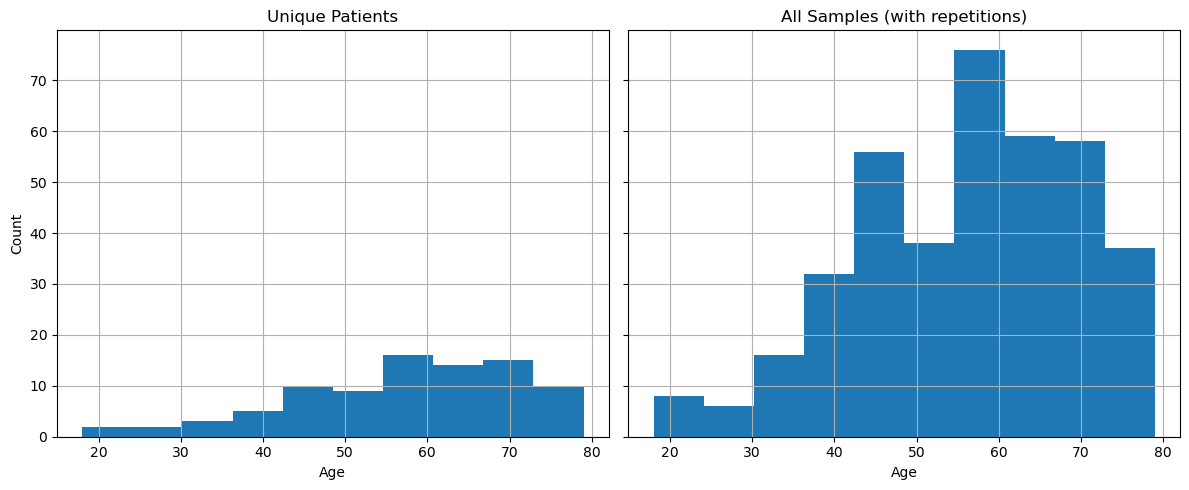

In [64]:
#=======================================
#Plot age of unique patients and entries
#=======================================
import matplotlib.pyplot as plt

unique_patients = df_arraymeta.drop_duplicates(subset="patient")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# unique ages
unique_patients["age"].hist(bins=10, ax=axes[0])
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_title("Unique Patients")

# repeated ages
df_arraymeta["age"].hist(bins=10, ax=axes[1])
axes[1].set_xlabel("Age")
axes[1].set_title("All Samples (with repetitions)")

plt.tight_layout()
plt.savefig("age_histogram.png", dpi=300, bbox_inches="tight")


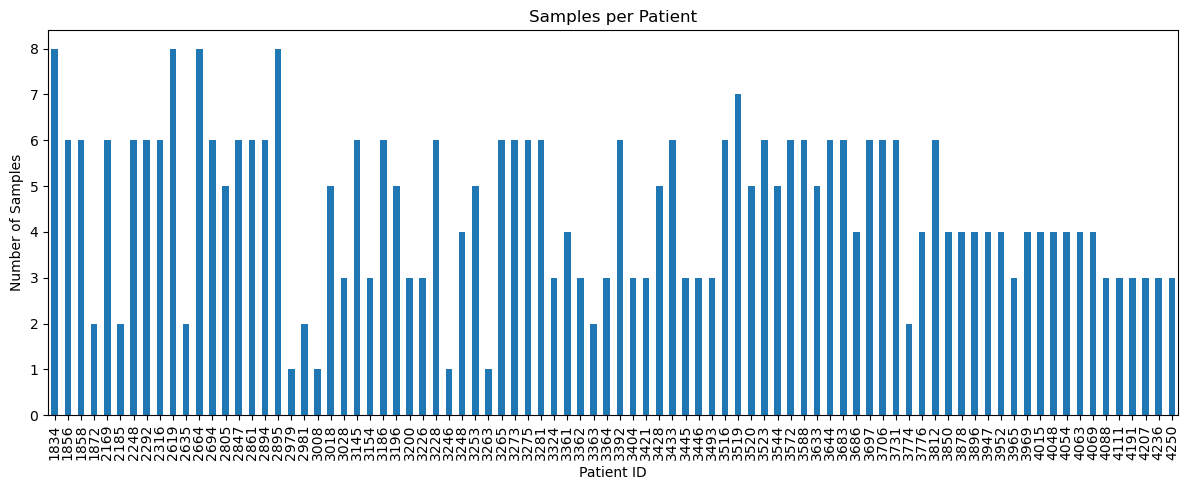

In [66]:
#======================================
#Plot number of repetitions per patient
#======================================
samples_per_patient = df_arraymeta["patient"].value_counts().sort_index()

ax = samples_per_patient.plot(kind="bar", figsize=(12, 5))
ax.set_xlabel("Patient ID")
ax.set_ylabel("Number of Samples")
ax.set_title("Samples per Patient")
plt.tight_layout()
plt.savefig("sample_counts_per_patient.png", dpi=300, bbox_inches="tight")


In [36]:
# Main cell
unique_patients = df_arraymeta.drop_duplicates(subset="patient")

# unique patients
counts_unique = {
    "<70": (unique_patients["age"] < 70).sum(),
    ">=70": (unique_patients["age"] >= 70).sum()
}
print("Counts (unique patients):", counts_unique)

# all samples
counts_all = {
    "<70": (df_arraymeta["age"] < 70).sum(),
    ">=70": (df_arraymeta["age"] >= 70).sum()
}
print("Counts (all samples):", counts_all)


Counts (unique patients): {'<70': 68, '>=70': 18}
Counts (all samples): {'<70': 320, '>=70': 66}


        entries_<70  entries_>=70  unique_<70  unique_>=70
region                                                    
ANCg            104            23          60           13
CB               70            11          44            8
DLPFC           146            32          67           18


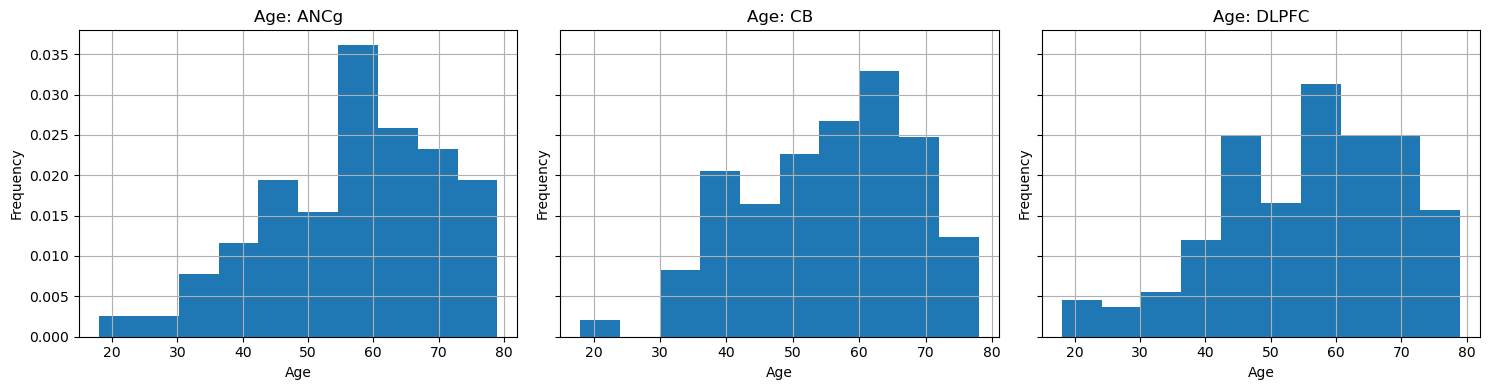

In [72]:
# Main cell
# Build region-specific subsets and plot their age histograms (unique bins for comparability)
regions = {
    "ANCg": "region.ancg",
    "CB": "region.cb",
    "DLPFC": "region.dlpfc",
}

subsets = {name: df_arraymeta[df_arraymeta[col] == 1] for name, col in regions.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = 10  # fixed across panels for fair comparison
for ax, (name, df_reg) in zip(axes, subsets.items()):
    df_reg["age"].hist(bins=bins, ax=ax,density=True)
    ax.set_title(f"Age: {name}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("age_histogram_region.png", dpi=300, bbox_inches="tight")

# Summary counts per region: entries vs unique patients, split at 70
summary_rows = []
for name, df_reg in subsets.items():
    uniq = df_reg.drop_duplicates(subset="patient")  # dedupe at patient level
    row = {
        "region": name,
        "entries_<70": (df_reg["age"] < 70).sum(),
        "entries_>=70": (df_reg["age"] >= 70).sum(),
        "unique_<70": (uniq["age"] < 70).sum(),
        "unique_>=70": (uniq["age"] >= 70).sum(),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("region")
print(summary_df)


             mean  median   iqr  range   variance
region                                           
ANCg    56.850394    58.0  19.0     61  13.229404
CB      55.197531    56.0  18.0     60  12.609936
DLPFC   55.820225    57.0  18.0     61  13.762359


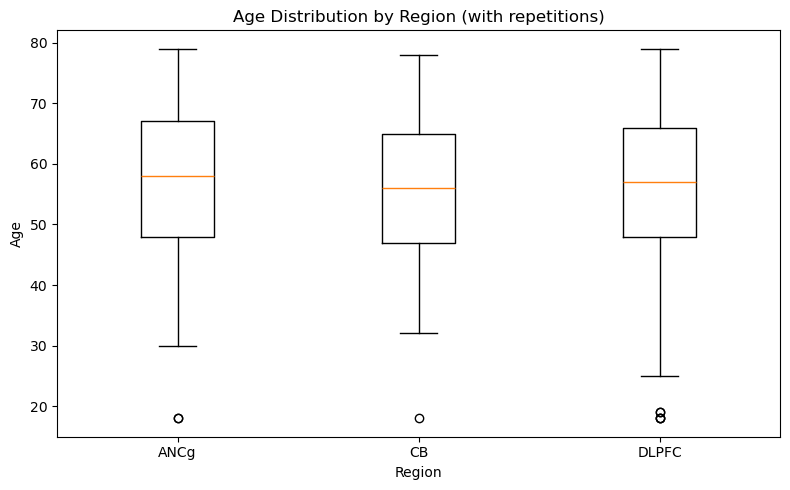

In [70]:
# Main cell
# Boxplots of age entries within each region
regions = {
    "ANCg": "region.ancg",
    "CB": "region.cb",
    "DLPFC": "region.dlpfc",
}

age_data = [df_arraymeta[df_arraymeta[col] == 1]["age"] for col in regions.values()]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(age_data, labels=regions.keys())
ax.set_xlabel("Region")
ax.set_ylabel("Age")
ax.set_title("Age Distribution by Region (with repetitions)")
plt.tight_layout()
plt.savefig("age_boxplot_region.png", dpi=300, bbox_inches="tight")

# Summary statistics per region
summary_rows = []
for name, col in regions.items():
    ages = df_arraymeta[df_arraymeta[col] == 1]["age"]
    row = {
        "region": name,
        "mean": ages.mean(),
        "median": ages.median(),
        "iqr": ages.quantile(0.75) - ages.quantile(0.25),
        "range": ages.max() - ages.min(),
        "variance": ages.std()
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("region")
print(summary_df)


               mean  median   iqr  range    variance    std_dev
lab                                                            
Davis     55.962264    57.5  20.0     61  196.569991  14.020342
Irvine    54.692308    56.0  17.0     61  158.042440  12.571493
Michigan  57.030675    59.0  18.0     61  179.634856  13.402793


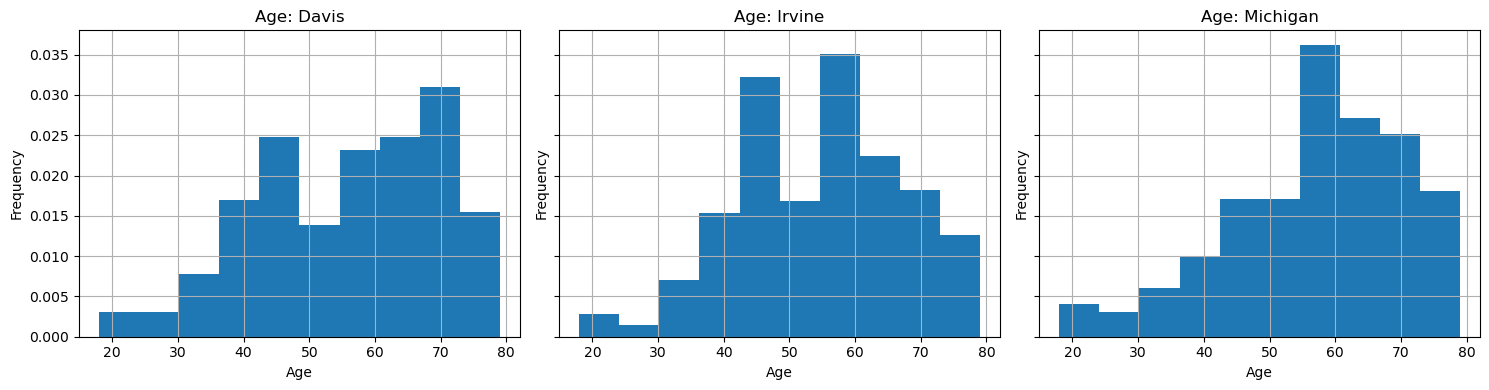

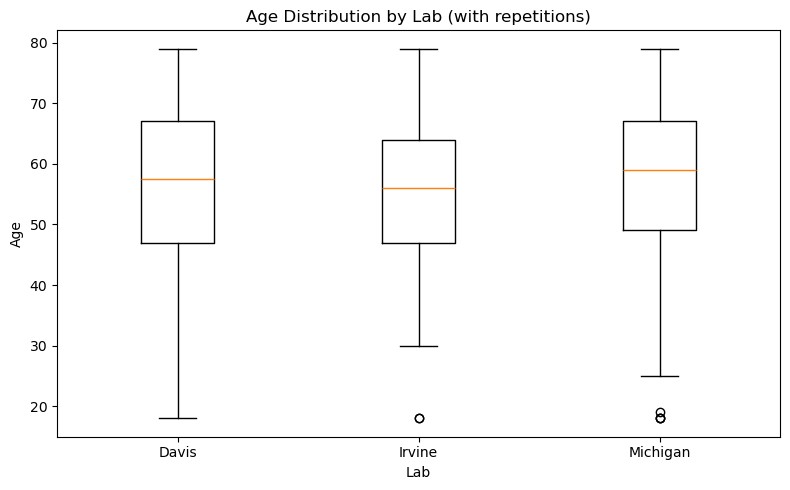

In [74]:
# Main cell
labs = {
    "Davis": "lab.davis",
    "Irvine": "lab.irvine",
    "Michigan": "lab.michigan",
}

subsets_lab = {name: df_arraymeta[df_arraymeta[col] == 1] for name, col in labs.items()}

# summary statistics
summary_rows = []
for name, df_lab in subsets_lab.items():
    ages = df_lab["age"]
    row = {
        "lab": name,
        "mean": ages.mean(),
        "median": ages.median(),
        "iqr": ages.quantile(0.75) - ages.quantile(0.25),
        "range": ages.max() - ages.min(),
        "variance": ages.var(),
        "std_dev": ages.std()
    }
    summary_rows.append(row)

summary_df_labs = pd.DataFrame(summary_rows).set_index("lab")
print(summary_df_labs)

# frequency histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins = 10
for ax, (name, df_lab) in zip(axes, subsets_lab.items()):
    df_lab["age"].hist(bins=bins, ax=ax, density=True)
    ax.set_title(f"Age: {name}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("age_histogram_lab.png", dpi=300, bbox_inches="tight")

# side by side boxplot
age_data_labs = [df_lab["age"] for df_lab in subsets_lab.values()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(age_data_labs, labels=labs.keys())
ax.set_xlabel("Lab")
ax.set_ylabel("Age")
ax.set_title("Age Distribution by Lab (with repetitions)")
plt.tight_layout()
plt.savefig("age_boxplot_lab.png", dpi=300, bbox_inches="tight")


             mean  median   iqr  range    variance    std_dev
sex                                                          
Male    54.178694    55.0  20.0     61  189.857613  13.778883
Female  61.694737    64.0  18.0     33   99.384546   9.969180


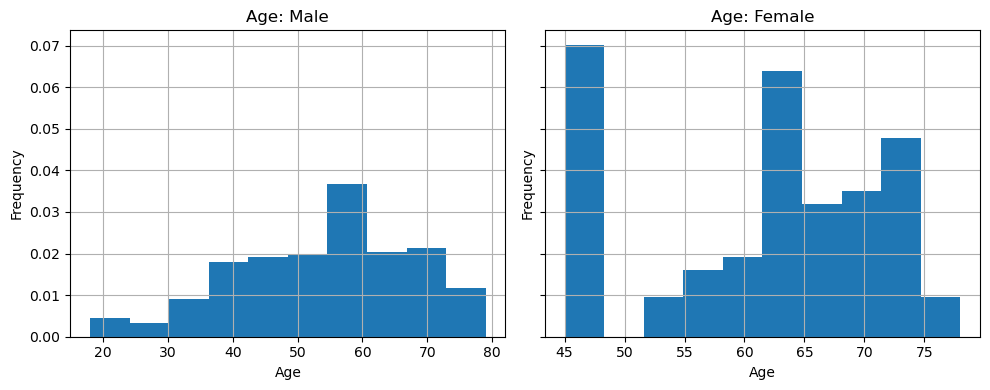

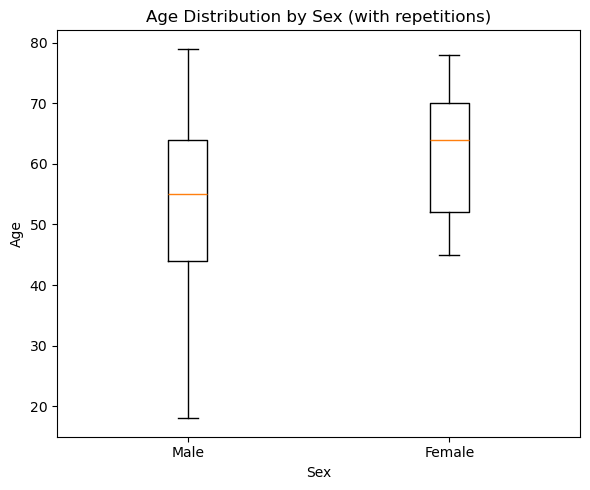

In [76]:
# Main cell
sex_groups = {
    "Male": df_arraymeta[df_arraymeta["sex"] == "M"],
    "Female": df_arraymeta[df_arraymeta["sex"] == "F"],
}

# frequency histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bins = 10
for ax, (name, df_sex) in zip(axes, sex_groups.items()):
    df_sex["age"].hist(bins=bins, ax=ax, density=True)
    ax.set_title(f"Age: {name}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("age_histogram_sex.png", dpi=300, bbox_inches="tight")

# side by side boxplot
age_data_sex = [df_sex["age"] for df_sex in sex_groups.values()]
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(age_data_sex, labels=sex_groups.keys())
ax.set_xlabel("Sex")
ax.set_ylabel("Age")
ax.set_title("Age Distribution by Sex (with repetitions)")
plt.tight_layout()
plt.savefig("age_boxplot_sex.png", dpi=300, bbox_inches="tight")

# summary statistics
summary_rows = []
for name, df_sex in sex_groups.items():
    ages = df_sex["age"]
    row = {
        "sex": name,
        "mean": ages.mean(),
        "median": ages.median(),
        "iqr": ages.quantile(0.75) - ages.quantile(0.25),
        "range": ages.max() - ages.min(),
        "variance": ages.var(),
        "std_dev": ages.std()
    }
    summary_rows.append(row)

summary_df_sex = pd.DataFrame(summary_rows).set_index("sex")
print(summary_df_sex)

              mean  median   iqr  range    variance    std_dev
version                                                       
1        53.241667    54.0  20.0     60  184.284449  13.575141
2        60.609589    63.0  14.0     49  134.308597  11.589159


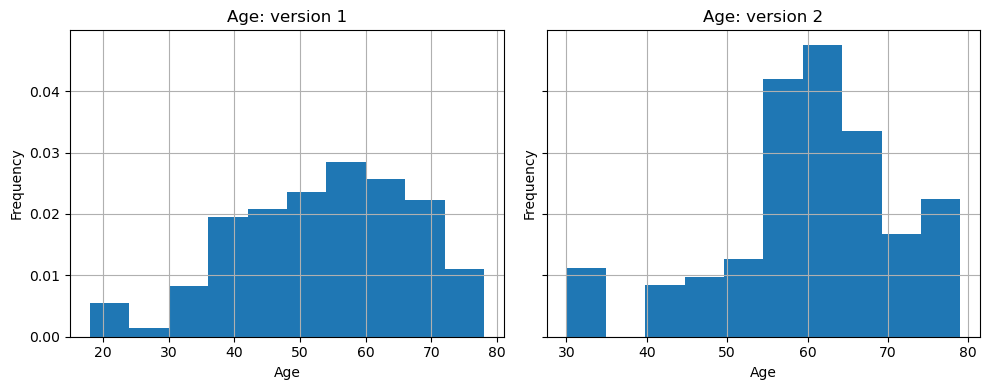

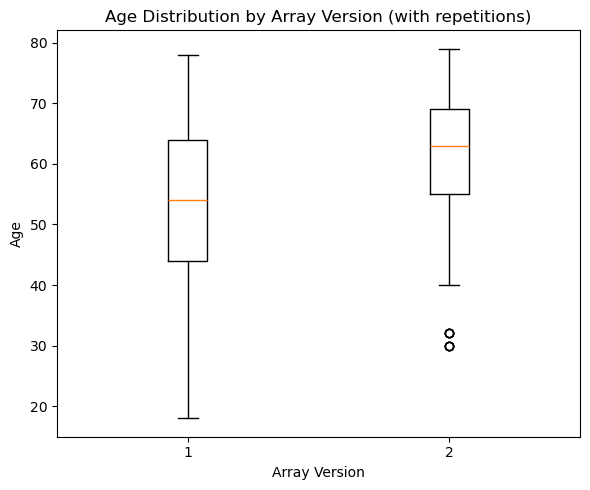

In [78]:
# Main cell
versions = {
    "1": df_arraymeta[df_arraymeta["arrayversion"] == 1],
    "2": df_arraymeta[df_arraymeta["arrayversion"] == 2],
}

# frequency histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bins = 10
for ax, (name, df_ver) in zip(axes, versions.items()):
    df_ver["age"].hist(bins=bins, ax=ax, density=True)
    ax.set_title(f"Age: version {name}")
    ax.set_xlabel("Age")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("age_histogram_version.png", dpi=300, bbox_inches="tight")

# summary statistics
summary_rows = []
for name, df_ver in versions.items():
    ages = df_ver["age"]
    row = {
        "version": name,
        "mean": ages.mean(),
        "median": ages.median(),
        "iqr": ages.quantile(0.75) - ages.quantile(0.25),
        "range": ages.max() - ages.min(),
        "variance": ages.var(),
        "std_dev": ages.std()
    }
    summary_rows.append(row)

summary_df_versions = pd.DataFrame(summary_rows).set_index("version")
print(summary_df_versions)

# side by side boxplot
age_data_versions = [df_ver["age"] for df_ver in versions.values()]
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(age_data_versions, labels=versions.keys())
ax.set_xlabel("Array Version")
ax.set_ylabel("Age")
ax.set_title("Age Distribution by Array Version (with repetitions)")
plt.tight_layout()
plt.savefig("age_boxplot_version.png", dpi=300, bbox_inches="tight")


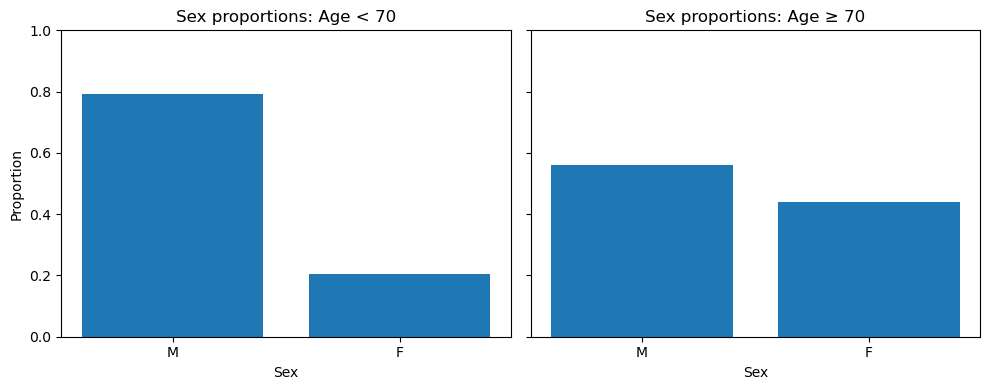

In [90]:
# Main cell
# Proportions of sex within age groups (<70 vs >=70); uses all entries (repetitions)
lt70 = df_arraymeta["age"] < 70
ge70 = df_arraymeta["age"] >= 70

sex_order = ["M", "F"]  # fix order for comparability
p_lt = df_arraymeta.loc[lt70, "sex"].value_counts(normalize=True).reindex(sex_order, fill_value=0)
p_ge = df_arraymeta.loc[ge70, "sex"].value_counts(normalize=True).reindex(sex_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(p_lt.index, p_lt.values)
axes[0].set_title("Sex proportions: Age < 70")
axes[0].set_xlabel("Sex"); axes[0].set_ylabel("Proportion"); axes[0].set_ylim(0, 1)

axes[1].bar(p_ge.index, p_ge.values)
axes[1].set_title("Sex proportions: Age ≥ 70")
axes[1].set_xlabel("Sex"); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("sex_proportion_within_grp.png", dpi=300, bbox_inches="tight")


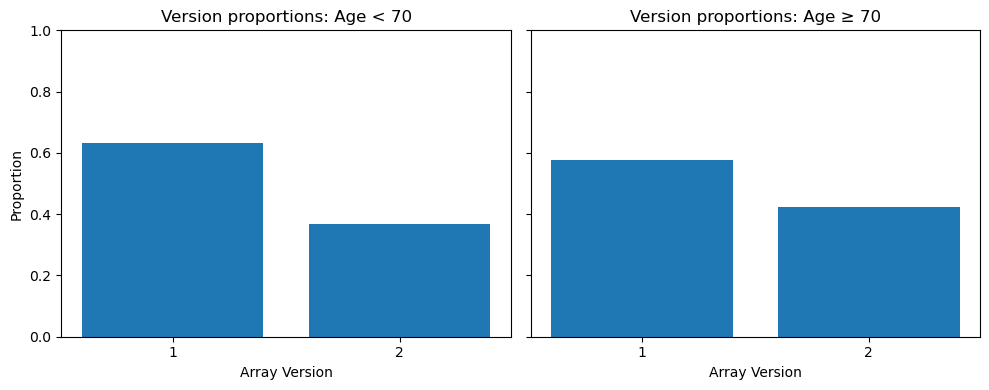

In [92]:
# Main cell
# Proportions of array version within age groups (<70 vs >=70); uses all entries (repetitions)
lt70 = df_arraymeta["age"] < 70
ge70 = df_arraymeta["age"] >= 70

ver_order = [1, 2]  # numeric versions
p_lt_v = df_arraymeta.loc[lt70, "arrayversion"].value_counts(normalize=True).reindex(ver_order, fill_value=0)
p_ge_v = df_arraymeta.loc[ge70, "arrayversion"].value_counts(normalize=True).reindex(ver_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(p_lt_v.index.astype(str), p_lt_v.values)
axes[0].set_title("Version proportions: Age < 70")
axes[0].set_xlabel("Array Version"); axes[0].set_ylabel("Proportion"); axes[0].set_ylim(0, 1)

axes[1].bar(p_ge_v.index.astype(str), p_ge_v.values)
axes[1].set_title("Version proportions: Age ≥ 70")
axes[1].set_xlabel("Array Version"); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("version_proportion_within_grp.png", dpi=300, bbox_inches="tight")


/var/folders/fk/nfp329xj1v3g44j1s4lnjb4w0000gr/T/ipykernel_72987/3800586141.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_arraymeta.groupby(["age_group", "lab_version"])
/var/folders/fk/nfp329xj1v3g44j1s4lnjb4w0000gr/T/ipykernel_72987/3800586141.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts["proportion"] = counts.groupby("age_group")["count"].transform(lambda x: x / x.sum())


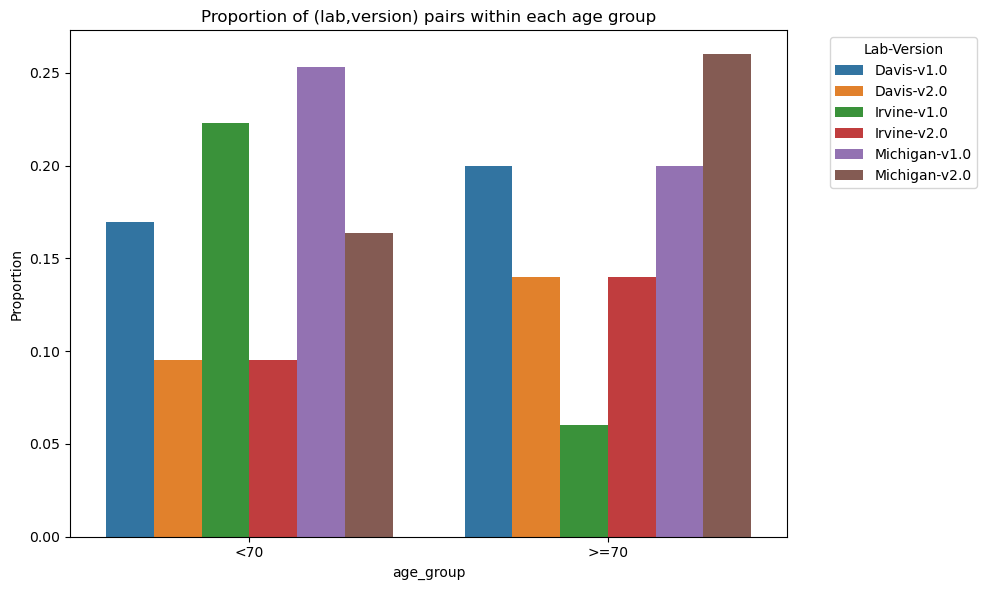

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make (lab, version) pair label
def lab_version_label(row):
    if row["lab.davis"] == 1:
        lab = "Davis"
    elif row["lab.irvine"] == 1:
        lab = "Irvine"
    elif row["lab.michigan"] == 1:
        lab = "Michigan"
    else:
        lab = "Unknown"
    return f"{lab}-v{row['arrayversion']}"

df_arraymeta = df_arraymeta.copy()
df_arraymeta["lab_version"] = df_arraymeta.apply(lab_version_label, axis=1)

# Define age group
df_arraymeta["age_group"] = pd.cut(df_arraymeta["age"], bins=[-float("inf"), 70, float("inf")], labels=["<70", ">=70"])

# Count samples
counts = (
    df_arraymeta.groupby(["age_group", "lab_version"])
    .size()
    .reset_index(name="count")
)

# Compute proportions within each age group
counts["proportion"] = counts.groupby("age_group")["count"].transform(lambda x: x / x.sum())

# Plot proportions
plt.figure(figsize=(10, 6))
sns.barplot(
    data=counts,
    x="age_group",
    y="proportion",
    hue="lab_version"
)
plt.ylabel("Proportion")
plt.title("Proportion of (lab,version) pairs within each age group")
plt.legend(title="Lab-Version", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("lab,version_proportion_within_grp.png", dpi=300, bbox_inches="tight")
plt.show()


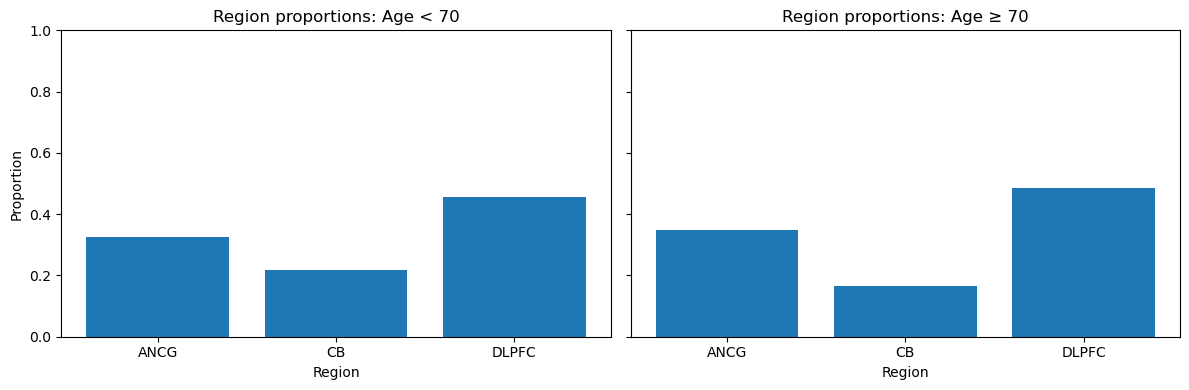

In [96]:
# Main cell
# Brain regions: proportions within age groups
lt70 = df_arraymeta["age"] < 70
ge70 = df_arraymeta["age"] >= 70

region_cols = ["region.ancg", "region.cb", "region.dlpfc"]

# count how many entries belong to each region (some patients may appear in multiple)
def region_proportions(mask):
    counts = {col.split(".")[1].upper(): df_arraymeta.loc[mask, col].sum() for col in region_cols}
    total = sum(counts.values())
    return {k: v / total if total > 0 else 0 for k, v in counts.items()}

p_lt_reg = region_proportions(lt70)
p_ge_reg = region_proportions(ge70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(p_lt_reg.keys(), p_lt_reg.values())
axes[0].set_title("Region proportions: Age < 70")
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Proportion"); axes[0].set_ylim(0, 1)

axes[1].bar(p_ge_reg.keys(), p_ge_reg.values())
axes[1].set_title("Region proportions: Age ≥ 70")
axes[1].set_xlabel("Region"); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("region_proportion_within_grp.png", dpi=300, bbox_inches="tight")


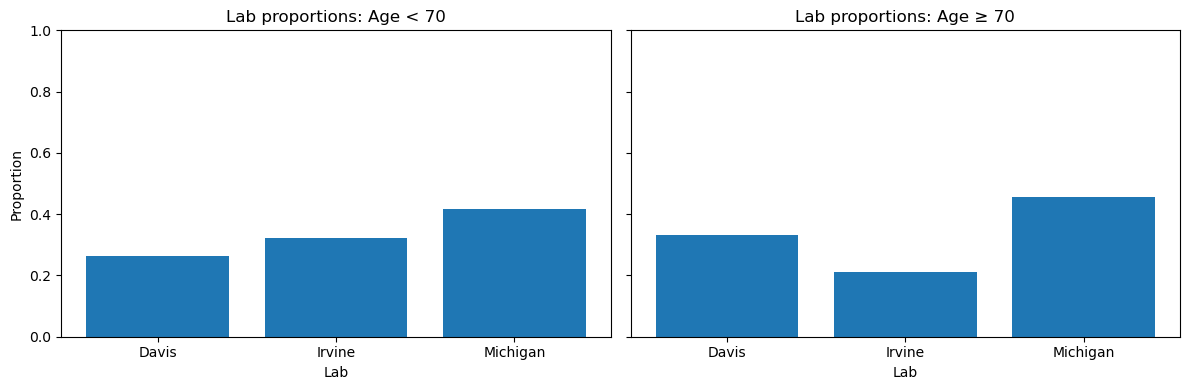

In [98]:
# Main cell
# Labs: proportions within age groups
lt70 = df_arraymeta["age"] < 70
ge70 = df_arraymeta["age"] >= 70

lab_cols = ["lab.davis", "lab.irvine", "lab.michigan"]

def lab_proportions(mask):
    counts = {col.split(".")[1].capitalize(): df_arraymeta.loc[mask, col].sum() for col in lab_cols}
    total = sum(counts.values())
    return {k: v / total if total > 0 else 0 for k, v in counts.items()}

p_lt_lab = lab_proportions(lt70)
p_ge_lab = lab_proportions(ge70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(p_lt_lab.keys(), p_lt_lab.values())
axes[0].set_title("Lab proportions: Age < 70")
axes[0].set_xlabel("Lab"); axes[0].set_ylabel("Proportion"); axes[0].set_ylim(0, 1)

axes[1].bar(p_ge_lab.keys(), p_ge_lab.values())
axes[1].set_title("Lab proportions: Age ≥ 70")
axes[1].set_xlabel("Lab"); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("lab_proportion_within_grp.png", dpi=300, bbox_inches="tight")


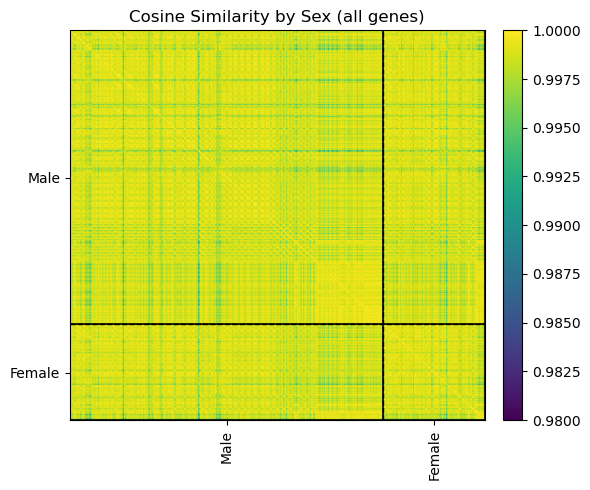

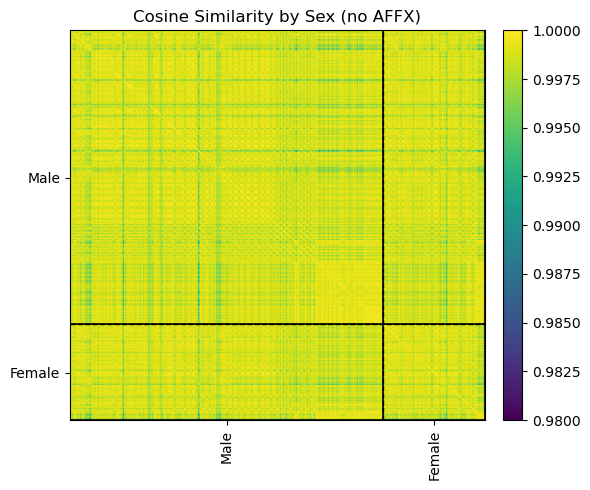

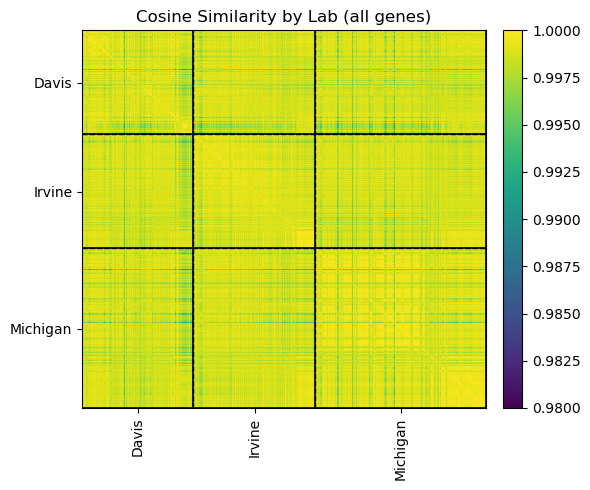

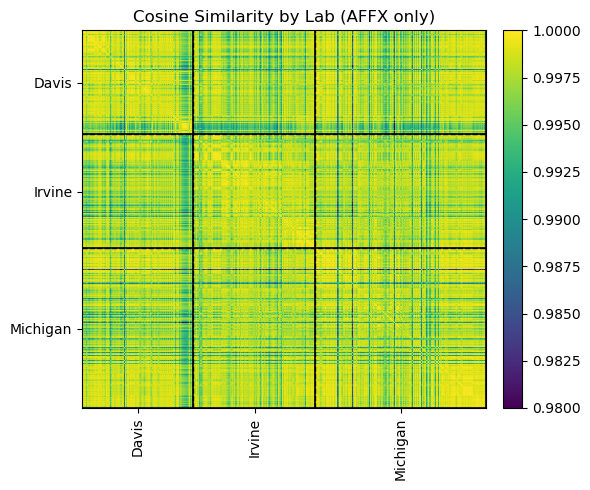

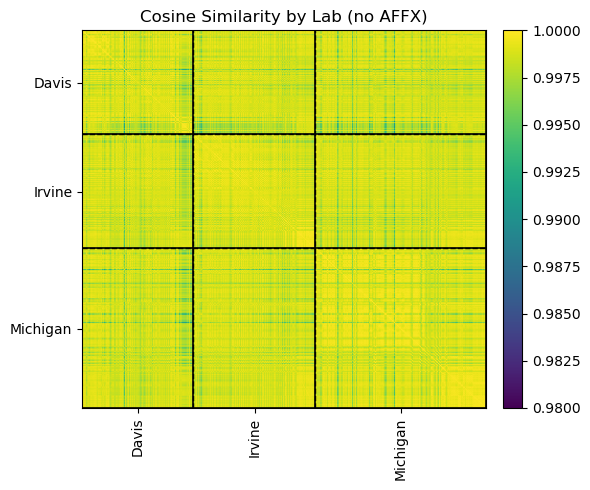

In [128]:
# Main cell
# Assumes df_expression rows align with df_arraymeta rows; reindex if needed before use.

# Main cell
def order_indices_by_groups(index, groups):
    # concat Index objects; avoid multi-arg .append
    ordered = [index[g] for g in groups]
    sizes = [len(i) for i in ordered]
    order_index = pd.Index(np.concatenate([i.to_numpy() for i in ordered]))
    return order_index, sizes

# Main cell
def cosine_heatmap(X, order_index, group_sizes, group_labels, title,vmin=0, vmax=1.0):
    Xo = X.loc[order_index]
    S = cosine_similarity(Xo.values)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(S, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

    # boundaries, labels, and gridlines
    cums = np.cumsum(group_sizes)
    mids = cums - np.array(group_sizes) / 2
    for b in cums[:-1]:
        ax.axhline(b - 0.5, linewidth=1, linestyle="--", color="k")
        ax.axvline(b - 0.5, linewidth=1, linestyle="--", color="k")

    # draw full block gridlines
    for b in cums:
        ax.axhline(b - 0.5, linewidth=1.2, color="k")
        ax.axvline(b - 0.5, linewidth=1.2, color="k")

    ax.set_yticks(mids)
    ax.set_yticklabels(group_labels)
    ax.set_xticks(mids)
    ax.set_xticklabels(group_labels, rotation=90)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

# Example usage
#sex_order, sex_sizes = order_indices_by_groups(df_arraymeta.index, [m_mask, f_mask])
#cosine_heatmap(X_all, sex_order, sex_sizes, ["Male", "Female"],
#               title="Cosine Similarity by Sex (all genes)")


# Masks for AFFX controls
affx_mask = df_expression.columns.str.startswith("AFFX")
X_all      = df_expression
X_no_affx  = df_expression.loc[:, ~affx_mask]
X_affx     = df_expression.loc[:,  affx_mask]

# 1) Sex groups, all genes
m_mask = df_arraymeta["sex"] == "M"
f_mask = df_arraymeta["sex"] == "F"
sex_order, sex_sizes = order_indices_by_groups(df_arraymeta.index, [m_mask, f_mask])
cosine_heatmap(X_all, sex_order, sex_sizes, ["Male", "Female"], title="Cosine Similarity by Sex (all genes)",vmin=0.98,vmax=1)

# 2) Sex groups, without AFFX
cosine_heatmap(X_no_affx, sex_order, sex_sizes, ["Male", "Female"], title="Cosine Similarity by Sex (no AFFX)",vmin=0.98,vmax=1)

# Lab masks
d_mask = df_arraymeta["lab.davis"] == 1
i_mask = df_arraymeta["lab.irvine"] == 1
mich_mask = df_arraymeta["lab.michigan"] == 1

# 3) Labs, all genes
lab_order, lab_sizes = order_indices_by_groups(df_arraymeta.index, [d_mask, i_mask, mich_mask])
cosine_heatmap(X_all, lab_order, lab_sizes, ["Davis", "Irvine", "Michigan"],title="Cosine Similarity by Lab (all genes)",vmin=0.98,vmax=1)

# 4) Labs, AFFX only
cosine_heatmap(X_affx, lab_order, lab_sizes, ["Davis", "Irvine", "Michigan"],title="Cosine Similarity by Lab (AFFX only)",vmin=0.98,vmax=1)

# 5) Labs, without AFFX
cosine_heatmap(X_no_affx, lab_order, lab_sizes, ["Davis", "Irvine", "Michigan"],title="Cosine Similarity by Lab (no AFFX)",vmin=0.98,vmax=1)


Summary statistics for pairwise cosine similarities:
{'min': 0.9898234678090054, 'max': 0.9999301008083876, 'mean': 0.9986229701404011, 'median': 0.9987872079593801, 'iqr': 0.0009655949201451408, 'range': (0.9898234678090054, 0.9999301008083876), 'variance': 7.620554669383414e-07, 'std_dev': 0.0008729578838285049}


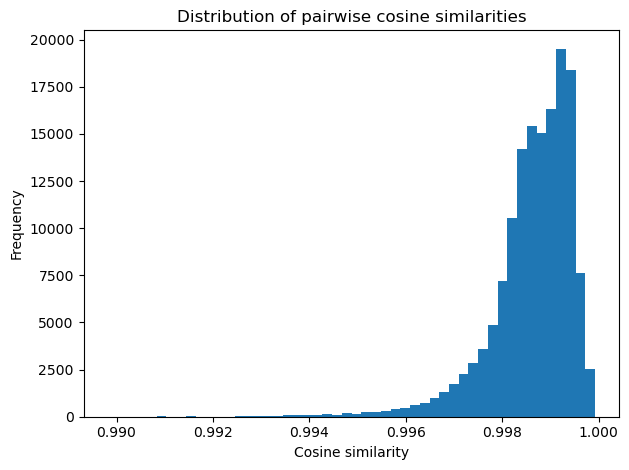

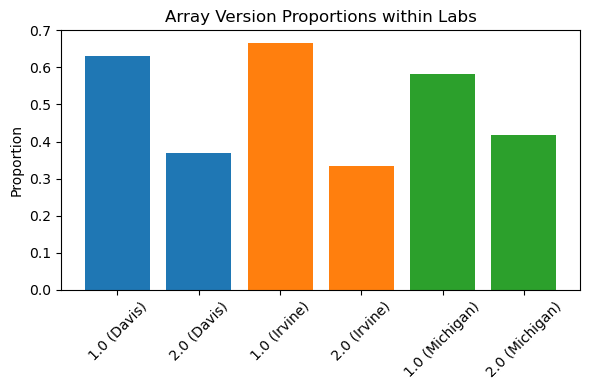

In [76]:
# Main cell

# 1) Histogram of cosine similarity across all expression vectors
S = cosine_similarity(df_expression.values)
np.fill_diagonal(S, np.nan)  # drop self-similarities (always 1)

vals = S[~np.isnan(S)].flatten()
plt.hist(vals, bins=50)
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.title("Distribution of pairwise cosine similarities")
plt.tight_layout()
plt.savefig("overall_cos_sim_dist.png", dpi=300, bbox_inches="tight")

summary_stats = {
    "min": np.min(vals),
    "max":np.max(vals),
    "mean": np.mean(vals),
    "median": np.median(vals),
    "iqr": np.quantile(vals, 0.75) - np.quantile(vals, 0.25),
    "range": (np.min(vals), np.max(vals)),
    "variance": np.var(vals),
    "std_dev": np.std(vals)
}
print("Summary statistics for pairwise cosine similarities:")
print(summary_stats)


# 2) Arrayversion proportions within each lab
lab_cols = ["lab.davis", "lab.irvine", "lab.michigan"]
labs = ["Davis", "Irvine", "Michigan"]

prop_rows = []
for lab_col, lab_name in zip(lab_cols, labs):
    df_lab = df_arraymeta[df_arraymeta[lab_col] == 1]
    counts = df_lab["arrayversion"].value_counts(normalize=True).sort_index()
    for ver, prop in counts.items():
        prop_rows.append({"Lab": lab_name, "Version": ver, "Proportion": prop})

prop_df = pd.DataFrame(prop_rows)

fig, ax = plt.subplots(figsize=(6, 4))
for lab_name in labs:
    subset = prop_df[prop_df["Lab"] == lab_name]
    ax.bar(subset["Version"].astype(str) + " (" + lab_name + ")", subset["Proportion"])

ax.set_ylabel("Proportion")
ax.set_title("Array Version Proportions within Labs")
plt.xticks(rotation=45)
plt.tight_layout()


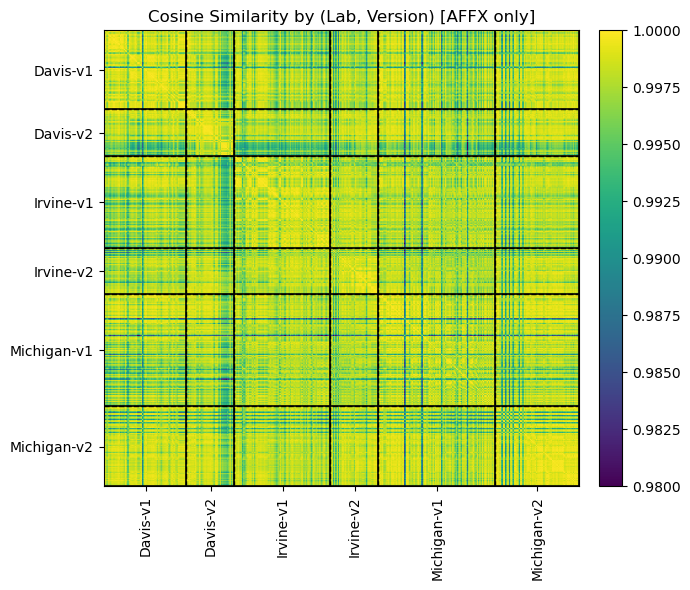

In [147]:
# Main cell

def cosine_heatmap_groups(X, meta, lab_cols, labs, versions,
                          use_affx="all", vmin=0.95, vmax=1.0,
                          title="Cosine Similarity by (Lab, Array Version)"):

    # choose subset of expression columns
    affx_mask = X.columns.str.startswith("AFFX")
    if use_affx == "all":
        X_use = X
    elif use_affx == "only":
        X_use = X.loc[:, affx_mask]
    elif use_affx == "none":
        X_use = X.loc[:, ~affx_mask]
    else:
        raise ValueError("use_affx must be 'all', 'only', or 'none'")

    # build groups
    groups, labels = [], []
    for lab_col, lab_name in zip(lab_cols, labs):
        for ver in versions:
            mask = (meta[lab_col] == 1) & (meta["arrayversion"] == ver)
            if mask.sum() > 0:
                groups.append(mask)
                labels.append(f"{lab_name}-v{ver}")

    order_index, group_sizes = order_indices_by_groups(meta.index, groups)

    # compute cosine similarity
    Xo = X_use.loc[order_index]
    S = cosine_similarity(Xo.values)

    # plot
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(S, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title)

    cums = np.cumsum(group_sizes)
    mids = cums - np.array(group_sizes) / 2
    for b in cums[:-1]:
        ax.axhline(b - 0.5, linewidth=1, linestyle="--", color="k")
        ax.axvline(b - 0.5, linewidth=1, linestyle="--", color="k")
    for b in cums:
        ax.axhline(b - 0.5, linewidth=1.2, color="k")
        ax.axvline(b - 0.5, linewidth=1.2, color="k")

    ax.set_yticks(mids)
    ax.set_yticklabels(labels)
    ax.set_xticks(mids)
    ax.set_xticklabels(labels, rotation=90)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig("cos_sim_(lab,version)grouping_affx_only.png", dpi=300, bbox_inches="tight")


# Example usage
lab_cols = ["lab.davis", "lab.irvine", "lab.michigan"]
labs = ["Davis", "Irvine", "Michigan"]
versions = [1, 2]

cosine_heatmap_groups(df_expression, df_arraymeta,
                      lab_cols, labs, versions,
                      use_affx="only",
                      vmin=0.98, vmax=1.0,
                      title="Cosine Similarity by (Lab, Version) [AFFX only]")


{'AFFX_cosine_median': 0.998035296331121, 'AFFX_cosine_MAD': 0.0016845945437580997}


(<Figure size 700x600 with 2 Axes>,
 <Axes: title={'center': 'Standardized Cosine Similarity (AFFX) by (Lab, Version)'}>)

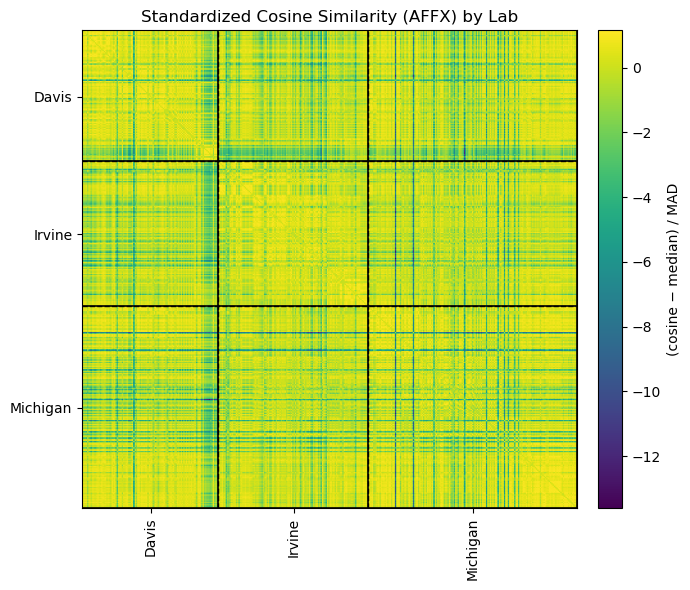

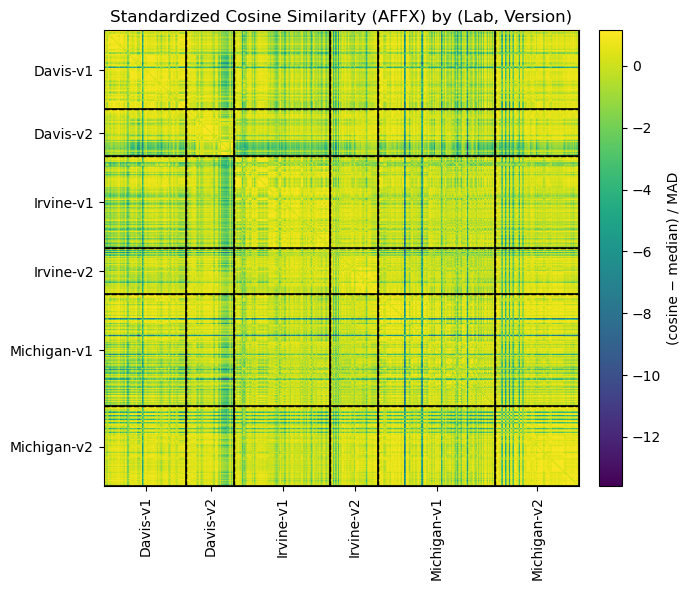

In [136]:
# Main cell
# Standardize cosine similarities on AFFX columns and plot grouped heatmaps:
# (i) by Lab; (ii) by (Lab, ArrayVersion). Uses median/MAD of the AFFX cosine distribution.

def cosine_standardized_affx(X):
    affx_mask = X.columns.str.startswith("AFFX")
    X_use = X.loc[:, affx_mask]
    S = cosine_similarity(X_use.values)
    np.fill_diagonal(S, np.nan)  # exclude trivial 1's from scaling
    vals = S[~np.isnan(S)]
    med = np.median(vals)
    mad = np.mean(np.abs(vals - med))
    mad = mad if mad != 0 else 1e-8  # guard for near-constant similarities
    Z = (S - med) / mad
    np.fill_diagonal(Z, 0.0)  # neutral diagonal
    return Z, med, mad

def grouped_order(index, masks):
    idxs = [index[m] for m in masks]
    sizes = [len(i) for i in idxs]
    order = pd.Index(np.concatenate([i.to_numpy() for i in idxs]))
    return order, sizes

# Main cell
def plot_grouped_heatmap(Z, order, sizes, labels, title, save=True):
    Zo = Z[np.ix_(order, order)]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(Zo, aspect="auto")
    ax.set_title(title)

    cums = np.cumsum(sizes)
    mids = cums - np.array(sizes) / 2
    for b in cums[:-1]:
        ax.axhline(b - 0.5, linewidth=1, linestyle="--", color="k")
        ax.axvline(b - 0.5, linewidth=1, linestyle="--", color="k")
    for b in cums:
        ax.axhline(b - 0.5, linewidth=1.2, color="k")
        ax.axvline(b - 0.5, linewidth=1.2, color="k")

    ax.set_yticks(mids); ax.set_yticklabels(labels)
    ax.set_xticks(mids); ax.set_xticklabels(labels, rotation=90)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="(cosine − median) / MAD")
    plt.tight_layout()

    if save:
        # sanitize title for filename
        fname = title.lower().replace(" ", "_").replace("(", "").replace(")", "")
        plt.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")

    return fig, ax

# compute standardized cosine (AFFX columns)
Z_affx, med_affx, mad_affx = cosine_standardized_affx(df_expression)
print({"AFFX_cosine_median": med_affx, "AFFX_cosine_MAD": mad_affx})

# (i) Group by Lab
lab_cols = ["lab.davis", "lab.irvine", "lab.michigan"]
lab_labels = ["Davis", "Irvine", "Michigan"]
lab_masks = [(df_arraymeta[c] == 1) for c in lab_cols]
lab_order, lab_sizes = grouped_order(df_arraymeta.index, lab_masks)
plot_grouped_heatmap(Z_affx, lab_order, lab_sizes, lab_labels,
                     title="Standardized Cosine Similarity (AFFX) by Lab")

# (ii) Group by (Lab, ArrayVersion)
versions = [1, 2]
pair_masks, pair_labels = [], []
for c, lname in zip(lab_cols, lab_labels):
    for v in versions:
        m = (df_arraymeta[c] == 1) & (df_arraymeta["arrayversion"] == v)
        if m.any():
            pair_masks.append(m)
            pair_labels.append(f"{lname}-v{v}")

pair_order, pair_sizes = grouped_order(df_arraymeta.index, pair_masks)
plot_grouped_heatmap(Z_affx, pair_order, pair_sizes, pair_labels,
                     title="Standardized Cosine Similarity (AFFX) by (Lab, Version)")


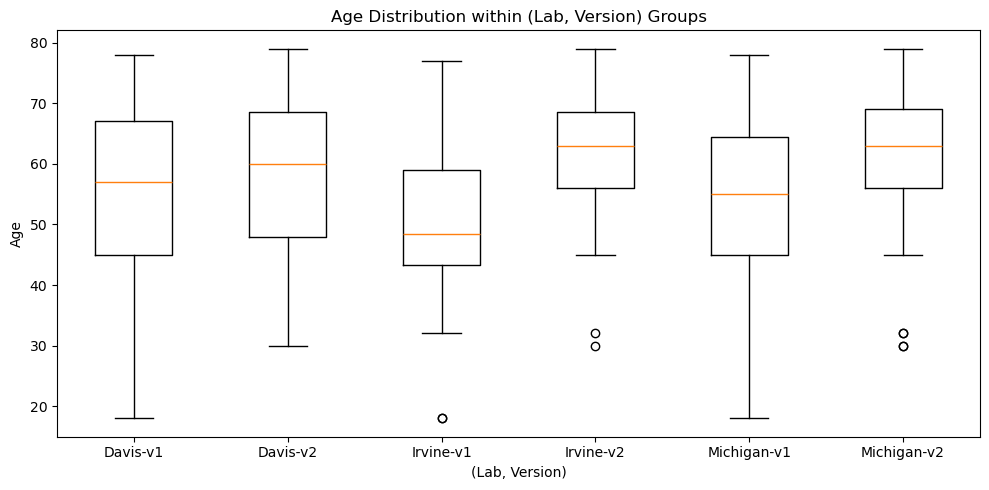

In [145]:
# Main cell
# derive lab label per row
lab_cols = ["lab.davis", "lab.irvine", "lab.michigan"]
lab_map = {"lab.davis": "Davis", "lab.irvine": "Irvine", "lab.michigan": "Michigan"}
lab_series = df_arraymeta[lab_cols].idxmax(axis=1).map(lab_map)

# build (lab,version) label
pair_series = lab_series + "-v" + df_arraymeta["arrayversion"].astype(int).astype(str)

# prepare data for boxplot
order = [f"{lab}-v{v}" for lab in ["Davis", "Irvine", "Michigan"] for v in (1, 2)]
age_data = [df_arraymeta.loc[pair_series == grp, "age"] for grp in order if (pair_series == grp).any()]

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(age_data, labels=[grp for grp in order if (pair_series == grp).any()])
ax.set_xlabel("(Lab, Version)")
ax.set_ylabel("Age")
ax.set_title("Age Distribution within (Lab, Version) Groups")
plt.tight_layout()
plt.savefig("age_dist_(lab,version)grouping.png", dpi=300, bbox_inches="tight")


In [149]:
# Main cell
# derive lab label per row
lab_cols = ["lab.davis", "lab.irvine", "lab.michigan"]
lab_map = {"lab.davis": "Davis", "lab.irvine": "Irvine", "lab.michigan": "Michigan"}
lab_series = df_arraymeta[lab_cols].idxmax(axis=1).map(lab_map)

# build (lab,version) label
pair_series = lab_series + "-v" + df_arraymeta["arrayversion"].astype(int).astype(str)

# counts of samples
counts = pair_series.value_counts().sort_index()
print(counts)


Davis-v1       67
Davis-v2       39
Irvine-v1      78
Irvine-v2      39
Michigan-v1    95
Michigan-v2    68
Name: count, dtype: int64


In [185]:
# Main cell
# Count number of samples within each (brain region, age group) combination

regions = {
    "ANCg": "region.ancg",
    "CB": "region.cb",
    "DLPFC": "region.dlpfc",
}

age_group = np.where(df_arraymeta["age"] < 70, "<70", "≥70")

rows = []
for rname, rcol in regions.items():
    mask = df_arraymeta[rcol] == 1
    if mask.sum() == 0:
        continue
    counts = pd.Series(age_group[mask]).value_counts().to_dict()
    rows.append({
        "region": rname,
        "<70": counts.get("<70", 0),
        "≥70": counts.get("≥70", 0),
        "total": mask.sum()
    })

table = pd.DataFrame(rows).set_index("region")
print(table)


        <70  ≥70  total
region                 
ANCg    104   23    127
CB       70   11     81
DLPFC   146   32    178


In [191]:
# Main cell
# Count number of samples in each (brain region, lab, arrayversion) group

regions = {
    "ANCg": "region.ancg",
    "CB": "region.cb",
    "DLPFC": "region.dlpfc",
}
labs = {
    "Davis": "lab.davis",
    "Irvine": "lab.irvine",
    "Michigan": "lab.michigan",
}
versions = [1, 2]

rows = []
for rname, rcol in regions.items():
    for lname, lcol in labs.items():
        for v in versions:
            mask = (df_arraymeta[rcol] == 1) & (df_arraymeta[lcol] == 1) & (df_arraymeta["arrayversion"] == v)
            n = mask.sum()
            if n > 0:
                rows.append({"region": rname, "lab": lname, "version": v, "count": n})

table = pd.DataFrame(rows).sort_values(["region", "lab", "version"]).reset_index(drop=True)
print(table)


   region       lab  version  count
0    ANCg    Irvine        1     36
1    ANCg    Irvine        2     30
2    ANCg  Michigan        1     31
3    ANCg  Michigan        2     30
4      CB     Davis        1     11
5      CB     Davis        2     10
6      CB    Irvine        1     33
7      CB    Irvine        2      9
8      CB  Michigan        1      9
9      CB  Michigan        2      9
10  DLPFC     Davis        1     56
11  DLPFC     Davis        2     29
12  DLPFC    Irvine        1      9
13  DLPFC  Michigan        1     55
14  DLPFC  Michigan        2     29


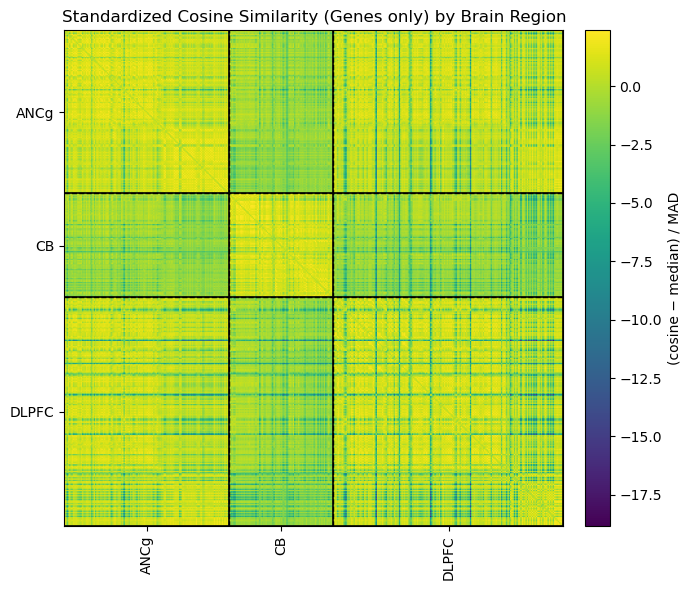

In [33]:
# Main cell
# Standardized cosine similarity heatmap (genes only; no AFFX), grouped by brain region

def cosine_standardized_noaffx(X):
    # remove AFFX controls; standardize similarities by median/MAD of off-diagonals
    mask = ~X.columns.str.startswith("AFFX")
    Xg = X.loc[:, mask]
    S = cosine_similarity(Xg.values)
    np.fill_diagonal(S, np.nan)
    vals = S[~np.isnan(S)]
    med = np.median(vals)
    mad = np.median(np.abs(vals - med)) or 1e-8  # guard for zero MAD
    Z = (S - med) / mad
    np.fill_diagonal(Z, 0.0)
    return Z

def grouped_order(index, masks):
    idxs = [index[m] for m in masks]
    sizes = [len(i) for i in idxs]
    order = pd.Index(np.concatenate([i.to_numpy() for i in idxs]))
    return order, sizes

def plot_grouped_heatmap(Z, order, sizes, labels, title):
    Zo = Z[np.ix_(order, order)]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(Zo, aspect="auto")
    ax.set_title(title)

    cums = np.cumsum(sizes)
    mids = cums - np.array(sizes) / 2
    for b in cums[:-1]:
        ax.axhline(b - 0.5, linewidth=1, linestyle="--", color="k")
        ax.axvline(b - 0.5, linewidth=1, linestyle="--", color="k")
    for b in cums:
        ax.axhline(b - 0.5, linewidth=1.2, color="k")
        ax.axvline(b - 0.5, linewidth=1.2, color="k")

    ax.set_yticks(mids); ax.set_yticklabels(labels)
    ax.set_xticks(mids); ax.set_xticklabels(labels, rotation=90)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="(cosine − median) / MAD")
    plt.tight_layout()
    plt.savefig("cos_sim_region_grouped.png", dpi=300, bbox_inches="tight")

# build region groups
regions = {"ANCg": "region.ancg", "CB": "region.cb", "DLPFC": "region.dlpfc"}
region_masks = [(df_arraymeta[c] == 1) for c in regions.values()]
region_labels = list(regions.keys())
order_idx, sizes = grouped_order(df_arraymeta.index, region_masks)

# compute standardized cosine (genes only)
Z_noaffx = cosine_standardized_noaffx(df_expression)

# plot
plot_grouped_heatmap(Z_noaffx, order_idx, sizes, region_labels,
                     title="Standardized Cosine Similarity (Genes only) by Brain Region")


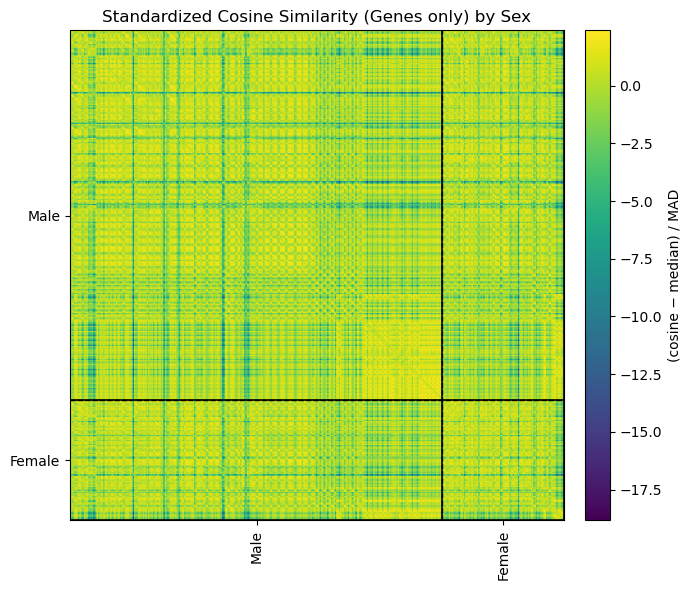

In [35]:
# Main cell
# Standardized cosine similarity heatmap (genes only; no AFFX), grouped by sex

def cosine_standardized_noaffx(X):
    mask = ~X.columns.str.startswith("AFFX")  # drop controls
    S = cosine_similarity(X.loc[:, mask].values)
    np.fill_diagonal(S, np.nan)
    vals = S[~np.isnan(S)]
    med = np.median(vals)
    mad = np.median(np.abs(vals - med)) or 1e-8  # guard for zero MAD
    Z = (S - med) / mad
    np.fill_diagonal(Z, 0.0)
    return Z

def grouped_order(index, masks):
    idxs = [index[m] for m in masks]
    sizes = [len(i) for i in idxs]
    order = pd.Index(np.concatenate([i.to_numpy() for i in idxs]))
    return order, sizes

def plot_grouped_heatmap(Z, order, sizes, labels, title):
    Zo = Z[np.ix_(order, order)]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(Zo, aspect="auto")
    ax.set_title(title)
    cums = np.cumsum(sizes)
    mids = cums - np.array(sizes) / 2
    for b in cums[:-1]:
        ax.axhline(b - 0.5, linewidth=1, linestyle="--", color="k")
        ax.axvline(b - 0.5, linewidth=1, linestyle="--", color="k")
    for b in cums:
        ax.axhline(b - 0.5, linewidth=1.2, color="k")
        ax.axvline(b - 0.5, linewidth=1.2, color="k")
    ax.set_yticks(mids); ax.set_yticklabels(labels)
    ax.set_xticks(mids); ax.set_xticklabels(labels, rotation=90)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="(cosine − median) / MAD")
    plt.tight_layout()
    plt.savefig("cos_sim_sex_grouped.png", dpi=300, bbox_inches="tight")

# build sex groups
sex_masks = [df_arraymeta["sex"] == "M", df_arraymeta["sex"] == "F"]
sex_labels = ["Male", "Female"]
order_idx, sizes = grouped_order(df_arraymeta.index, sex_masks)

# compute standardized cosine (genes only)
Z_noaffx = cosine_standardized_noaffx(df_expression)

# plot
plot_grouped_heatmap(Z_noaffx, order_idx, sizes, sex_labels,
                     title="Standardized Cosine Similarity (Genes only) by Sex")


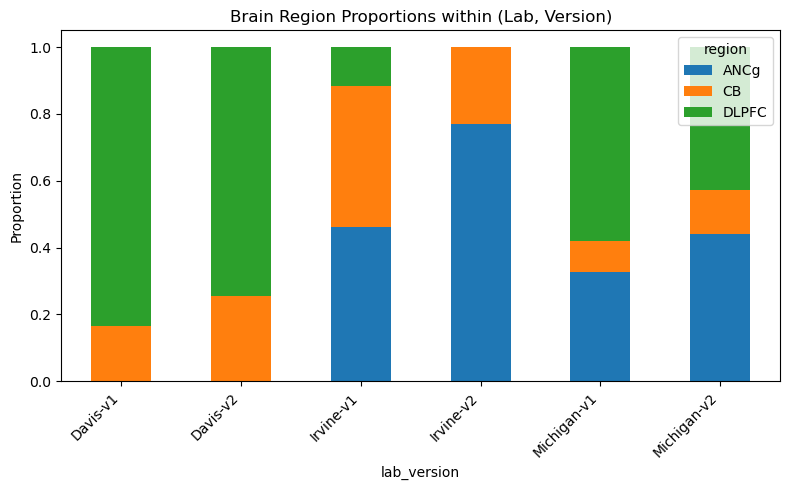

In [197]:
# Main cell
# Plot brain region proportions within each (lab,version) group

regions = {
    "ANCg": "region.ancg",
    "CB": "region.cb",
    "DLPFC": "region.dlpfc",
}
labs = {
    "Davis": "lab.davis",
    "Irvine": "lab.irvine",
    "Michigan": "lab.michigan",
}
versions = [1, 2]

# collect proportions
rows = []
for lname, lcol in labs.items():
    for v in versions:
        mask_lv = (df_arraymeta[lcol] == 1) & (df_arraymeta["arrayversion"] == v)
        if mask_lv.sum() == 0:
            continue
        total = mask_lv.sum()
        for rname, rcol in regions.items():
            n = (df_arraymeta[mask_lv][rcol] == 1).sum()
            prop = n / total if total > 0 else 0
            rows.append({"lab_version": f"{lname}-v{v}", "region": rname, "proportion": prop})

prop_df = pd.DataFrame(rows)

# plot stacked bar chart
pivot_df = prop_df.pivot(index="lab_version", columns="region", values="proportion").fillna(0)
ax = pivot_df.plot(kind="bar", stacked=True, figsize=(8, 5))
ax.set_ylabel("Proportion")
ax.set_title("Brain Region Proportions within (Lab, Version)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()


In [58]:
# Main cell — Train-only screening/LASSO; OLS + BH on test
# Steps:
# 1) split
# 2) screen genes by |corr|≥0.4 (train); build design = genes + non-ref indicators + (indicators×genes); LASSO (no standardization)
# 3) OLS on test using selected covariates; BH FDR to flag significant terms

import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.exceptions import ConvergenceWarning
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

alpha_bh = 0.1         # BH level
df_resid_min = 10      # keep residual dof for stable OLS
alphas = np.logspace(-4, 1, 40)

# 1) Split
genes_all = df_expression.columns[~df_expression.columns.str.startswith("AFFX")]
Xg_all = df_expression.loc[:, genes_all].astype(float)
y_all  = df_arraymeta["age"].astype(float)
Xg_tr, Xg_te, y_tr, y_te, meta_tr, meta_te = train_test_split(
    Xg_all, y_all, df_arraymeta, test_size=0.2, random_state=42
)

# Non-ref indicators builder (ref: region.cb, lab.michigan, sex=F, version=2)
def build_nonref_indicators(meta):
    return pd.DataFrame({
        "region.ancg":     (meta["region.ancg"]==1).astype(float),
        "region.dlpfc":    (meta["region.dlpfc"]==1).astype(float),
        "lab.davis":       (meta["lab.davis"]==1).astype(float),
        "lab.irvine":      (meta["lab.irvine"]==1).astype(float),
        "sex_M":           (meta["sex"]=="M").astype(float),
        "arrayversion_1":  (meta["arrayversion"]==1).astype(float),
    }, index=meta.index)

# 2) Train-side correlation screening (|corr|≥0.4) → LASSO on screened genes + indicators + interactions
# Corr screening
Xc = Xg_tr - Xg_tr.mean(axis=0)
yc = y_tr - y_tr.mean()
num = (Xc.values.T @ yc.values)
den = np.linalg.norm(Xc.values, axis=0) * np.linalg.norm(yc.values)
corr = num / den
keep_idx = np.flatnonzero(np.abs(corr) >= 0.2)
screened_genes = Xg_tr.columns[keep_idx]
print(f"Screened genes (|corr|≥0.4): {len(screened_genes)}")

if len(screened_genes) == 0:
    raise RuntimeError("No genes passed |corr|≥0.4. Relax threshold or add a fallback top-k.")

# Indicators (non-ref)
Xmeta_tr = build_nonref_indicators(meta_tr)

# Interactions (vectorized blocks)
G_tr = Xg_tr[screened_genes].astype(float).values
blocks, names = [], []
for m in Xmeta_tr.columns:
    mcol = Xmeta_tr[m].values[:, None]
    blk = G_tr * mcol
    blocks.append(blk)
    names += [f"{m}:{g}" for g in screened_genes]
Xint_tr = pd.DataFrame(np.hstack(blocks), index=Xg_tr.index, columns=names, dtype=float)

# Train design for LASSO (no scaling)
X_tr_design = pd.concat([Xg_tr[screened_genes].astype(float), Xmeta_tr.astype(float), Xint_tr], axis=1).astype(float)

lcv = LassoCV(alphas=alphas, cv=5, random_state=42, n_jobs=-1, max_iter=5000)
lcv.fit(X_tr_design, y_tr.values)

coef = pd.Series(lcv.coef_, index=X_tr_design.columns)
sel = coef[coef != 0.0]
print(f"Selected covariates (incl. interactions): {sel.size}")
# Also report non-interaction count
n_non_inter = sum(":" not in t for t in sel.index)
print(f"Selected non-interaction covariates: {n_non_inter}")

# 3) OLS on TEST using selected covariates; cap to ensure positive residual dof
# Build test-side pieces
Xmeta_te = build_nonref_indicators(meta_te)

# Assemble only selected columns; build interactions on demand
sel_terms = sel.index.tolist()
genes_sel = [t for t in sel_terms if ":" not in t and t in Xg_te.columns]
inds_sel  = [t for t in sel_terms if ":" not in t and t in Xmeta_te.columns]
ints_sel  = [t for t in sel_terms if ":" in t]

Xpieces = []
if genes_sel:
    Xpieces.append(Xg_te.loc[:, genes_sel].astype(float))
if inds_sel:
    Xpieces.append(Xmeta_te.loc[:, inds_sel].astype(float))
if ints_sel:
    need_by_ind = {}
    for term in ints_sel:
        ind, gene = term.split(":")
        need_by_ind.setdefault(ind, []).append(gene)
    Xints_parts = []
    for ind, glist in need_by_ind.items():
        if ind not in Xmeta_te.columns:
            Xints_parts.append(pd.DataFrame(0.0, index=Xg_te.index,
                                            columns=[f"{ind}:{g}" for g in glist]))
            continue
        mvec = Xmeta_te[ind].values[:, None]
        Gsub = Xg_te.loc[:, glist].values
        blk  = mvec * Gsub
        cols = [f"{ind}:{g}" for g in glist]
        Xints_parts.append(pd.DataFrame(blk, index=Xg_te.index, columns=cols, dtype=float))
    Xpieces.append(pd.concat(Xints_parts, axis=1))

X_test_full = pd.concat(Xpieces, axis=1).reindex(columns=sel_terms, fill_value=0.0).astype(float)

# Cap number of terms so df_resid ≥ df_resid_min; prioritize main effects, then interactions by |lasso coef|
n_test = X_test_full.shape[0]
max_terms = max(1, n_test - 1 - df_resid_min)

def score(t):  # higher |coef| first
    return float(abs(sel.get(t, 0.0)))

main_terms = sorted([t for t in sel_terms if ":" not in t], key=score, reverse=True)
int_terms  = sorted([t for t in sel_terms if ":" in t],  key=score, reverse=True)

kept = []
for group in (main_terms, int_terms):
    for t in group:
        if len(kept) < max_terms:
            kept.append(t)
        else:
            break
    if len(kept) >= max_terms:
        break

# Final test matrix
X_test_sel = X_test_full.loc[:, kept]
# Drop zero-variance cols
nz = X_test_sel.std(axis=0).replace(0, np.nan).notna()
X_test_sel = X_test_sel.loc[:, nz]

X_ols = sm.add_constant(X_test_sel)
ols = sm.OLS(y_te.values, X_ols).fit()
print(ols.summary())

# BH FDR on test p-values
pvals = ols.pvalues.drop("const", errors="ignore")
rej, qvals, _, _ = multipletests(pvals, alpha=alpha_bh, method="fdr_bh")
sig_covariates = pvals.index[rej].tolist()
print(f"\nSignificant covariates after BH FDR < {alpha_bh}:")
print(sig_covariates)


Screened genes (|corr|≥0.4): 234
Selected covariates (incl. interactions): 118
Selected non-interaction covariates: 37
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     14.37
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           4.06e-05
Time:                        14:23:21   Log-Likelihood:                -138.71
No. Observations:                  78   AIC:                             413.4
Df Residuals:                      10   BIC:                             573.7
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.9

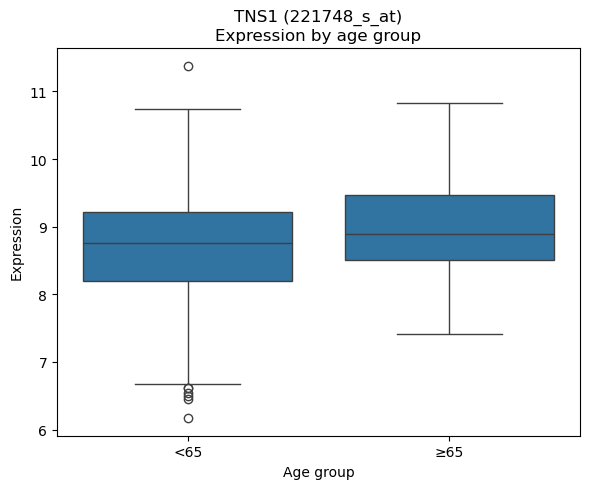

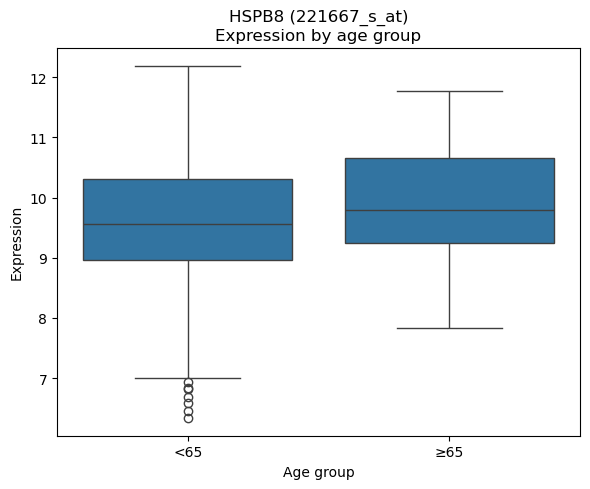

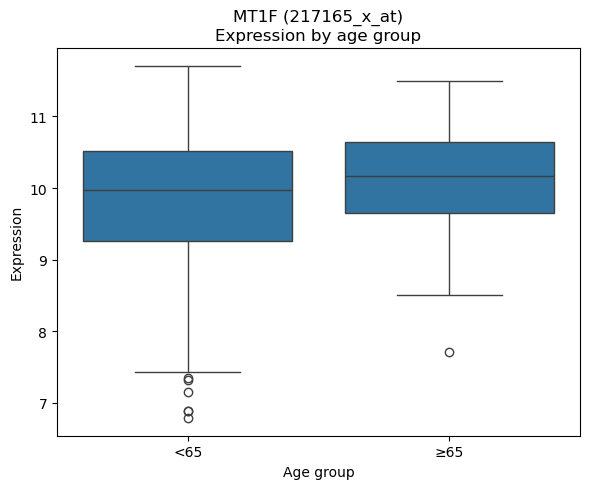

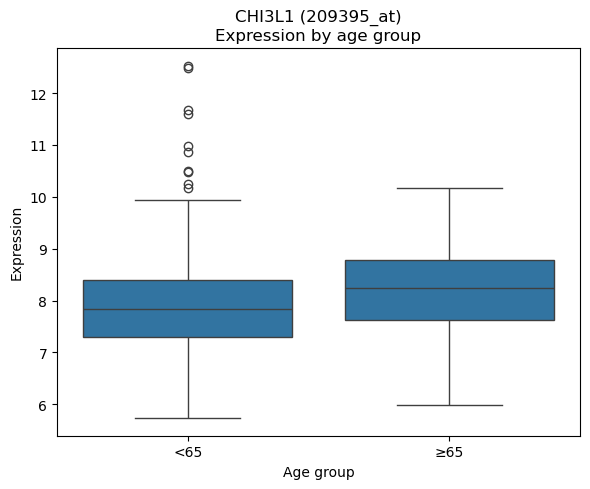

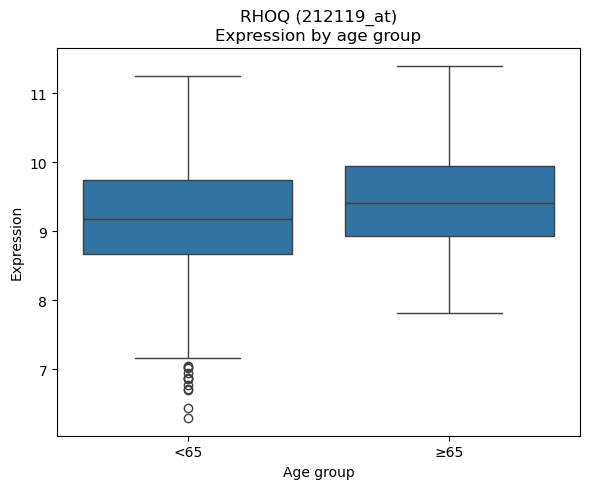

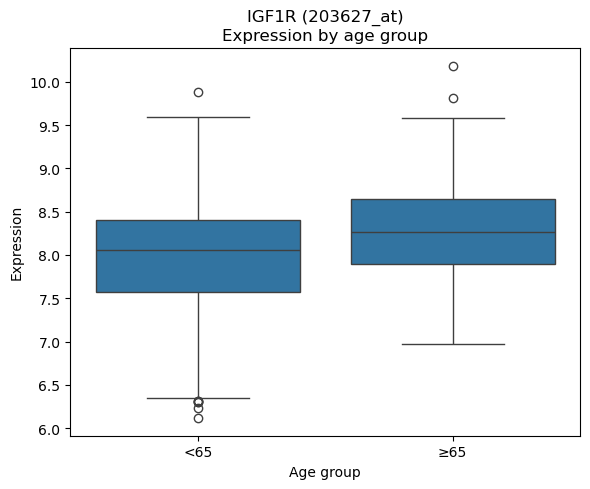

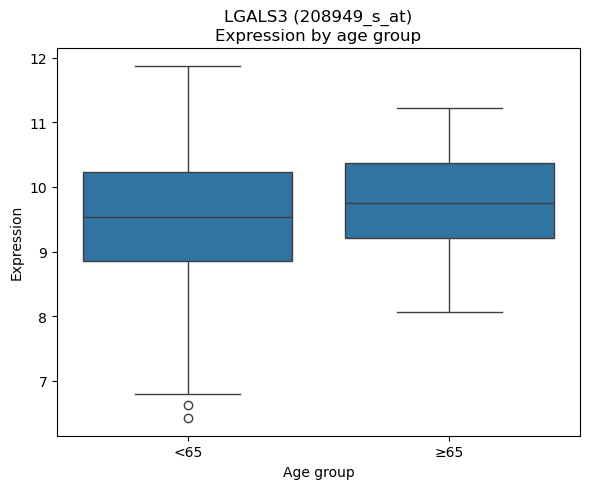

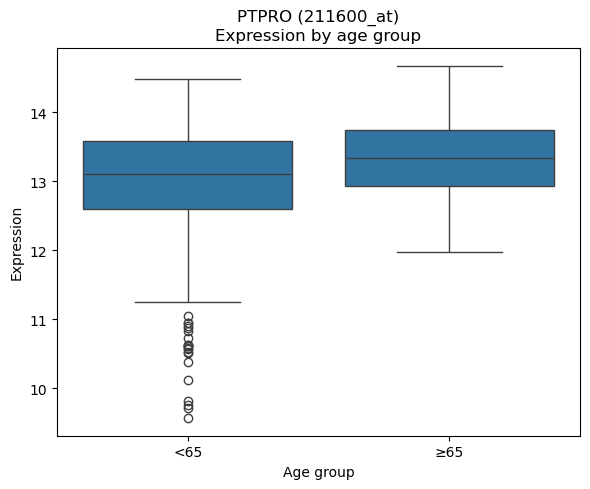

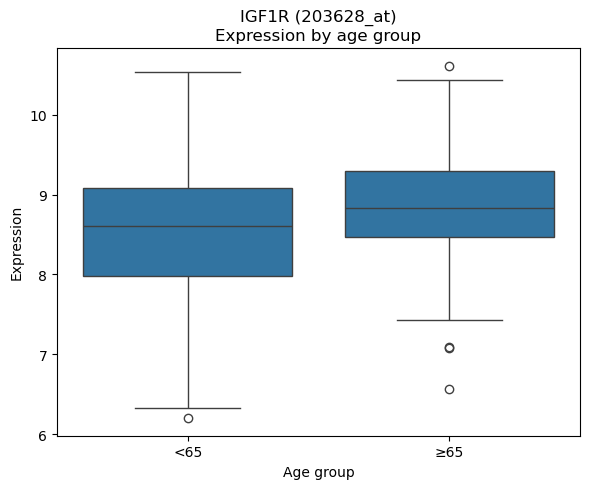

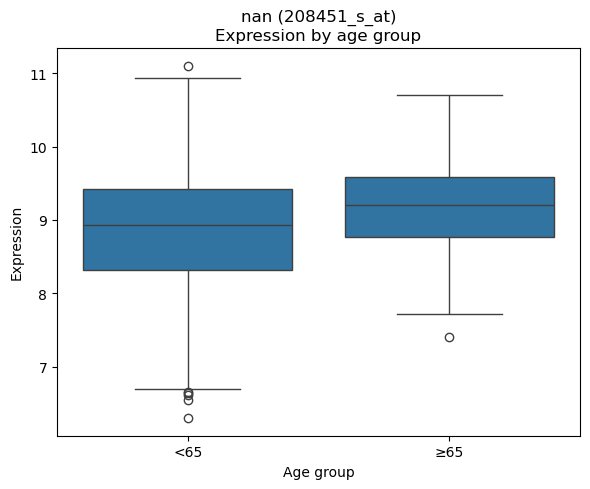

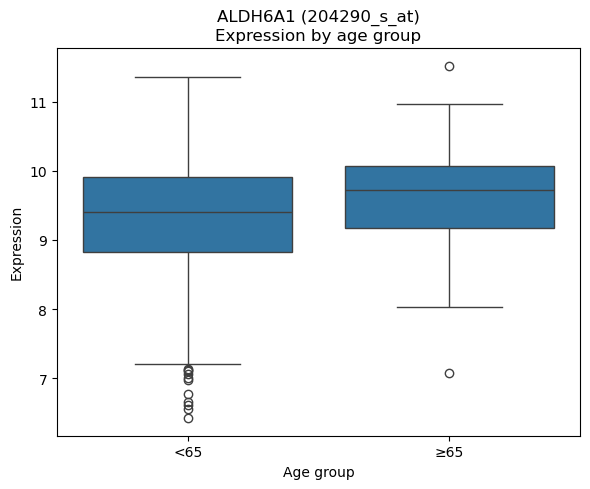

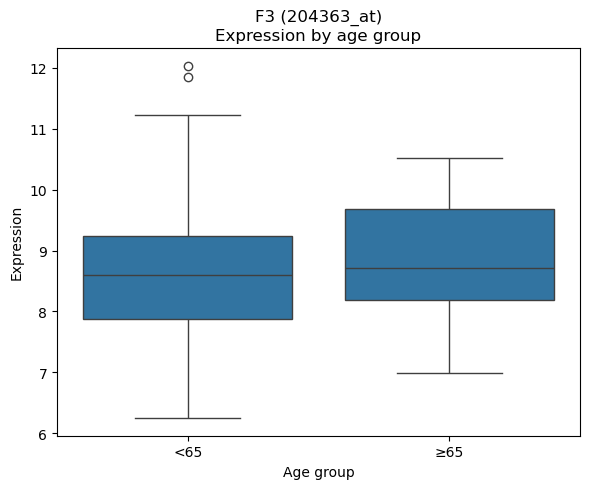

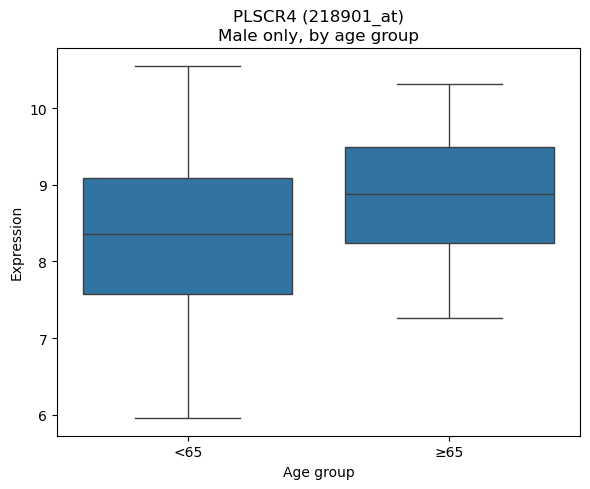

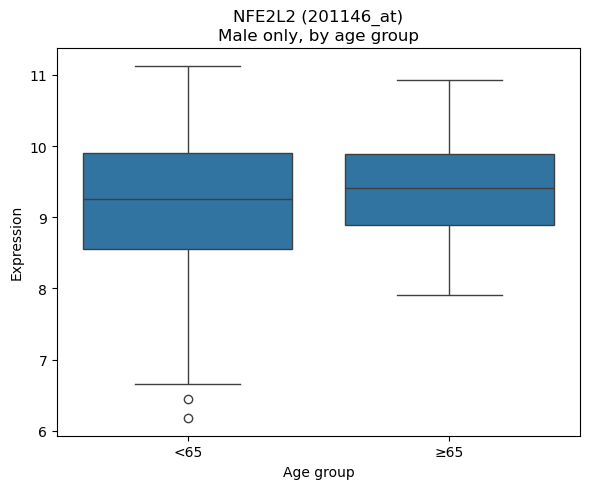

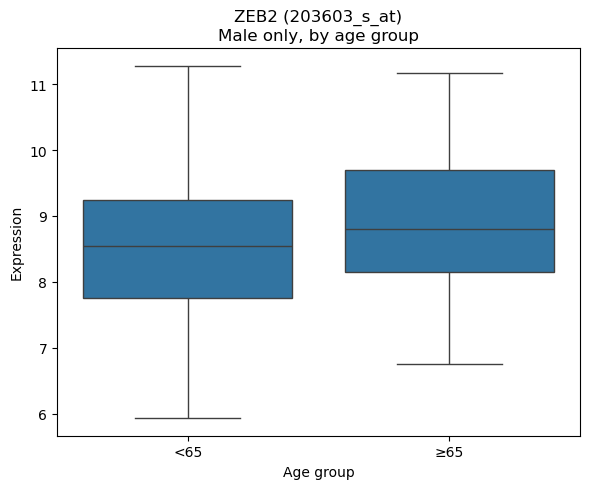

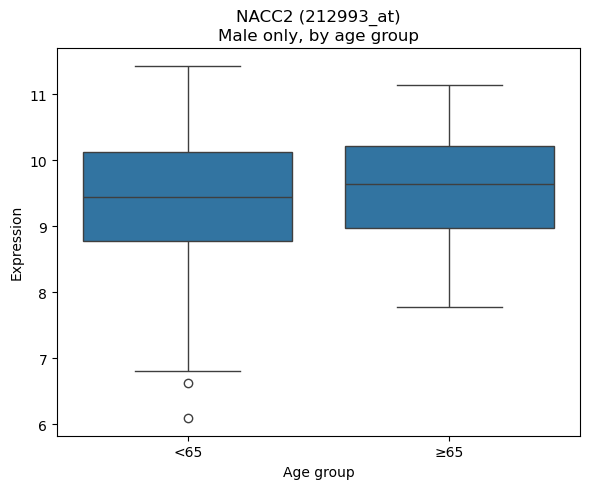

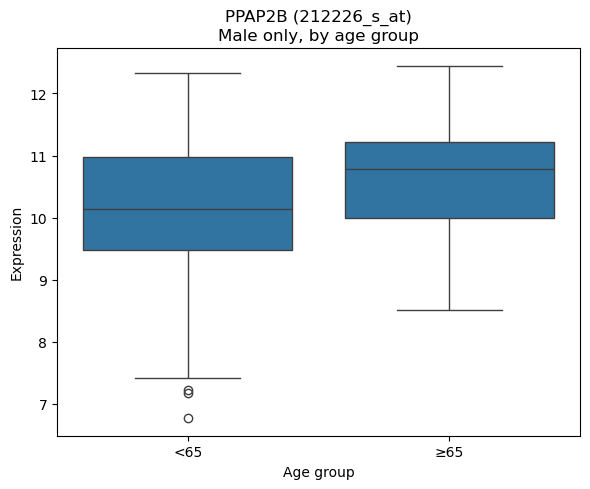

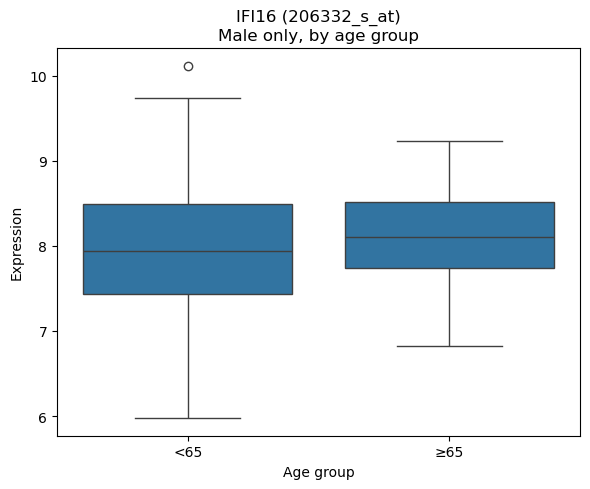

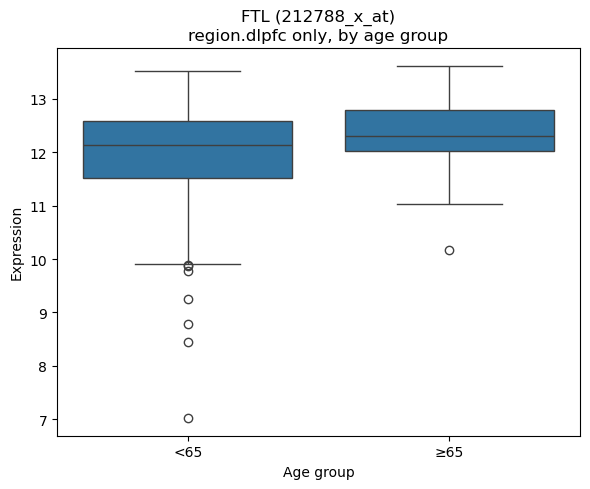

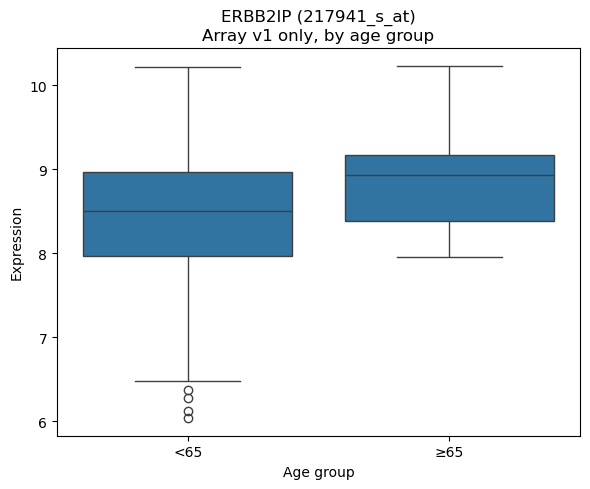

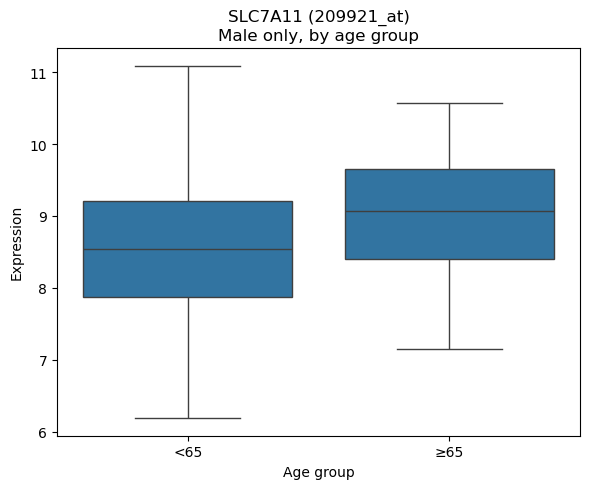

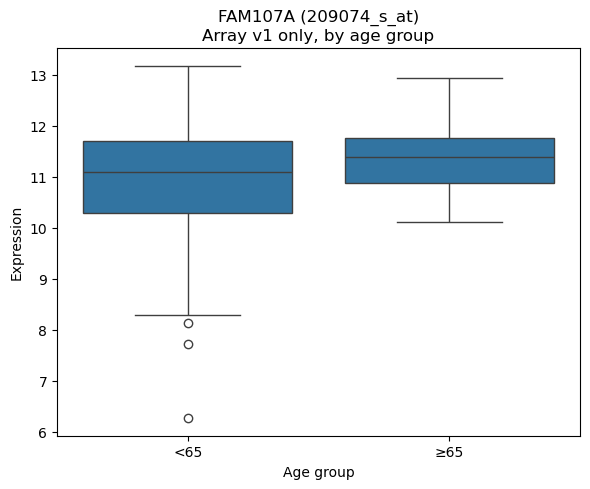

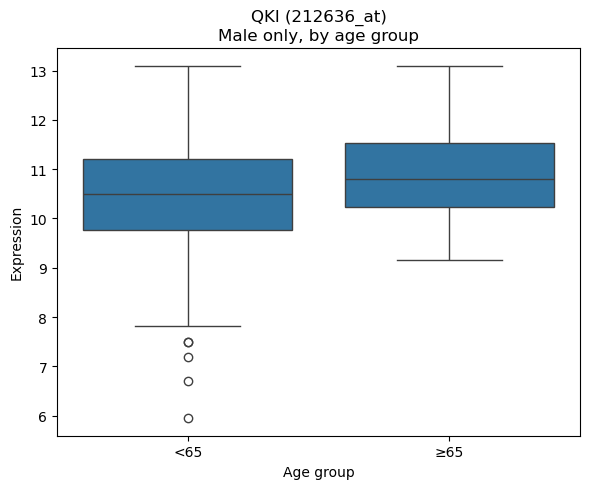

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# probe_to_symbol: dict from probe ID → gene symbol
probe_to_symbol = df_genemeta.loc["sym"].to_dict()
age_cutoff=65
# Add age group to metadata
meta_all = df_arraymeta.copy()
meta_all["age_group"] = np.where(meta_all["age"] < age_cutoff, f"<{age_cutoff}", f"≥{age_cutoff}")

def plot_sig_covariate(cov):
    plt.figure(figsize=(6,5))
    
    if ":" not in cov:
        # ---- main effect gene ----
        gene = cov
        symbol = probe_to_symbol.get(gene, gene)
        expr = df_expression[gene]
        df_plot = meta_all.assign(expr=expr.values)
        
        sns.boxplot(data=df_plot, x="age_group", y="expr")
        plt.title(f"{symbol} ({gene})\nExpression by age group")
        plt.ylabel("Expression")
        plt.xlabel("Age group")
    
    else:
        # ---- interaction term ----
        ind, gene = cov.split(":")
        symbol = probe_to_symbol.get(gene, gene)
        
        if ind == "sex_M":
            mask = meta_all["sex"] == "M"
            ind_label = "Male"
        elif ind == "arrayversion_1":
            mask = meta_all["arrayversion"] == 1
            ind_label = "Array v1"
        elif ind in meta_all.columns:  # lab/region indicators
            mask = meta_all[ind] == 1
            ind_label = ind
        else:
            print(f"Indicator {ind} not recognized, skipping {cov}")
            return
        
        df_sub = meta_all.loc[mask].assign(expr=df_expression.loc[mask, gene].values)
        sns.boxplot(data=df_sub, x="age_group", y="expr")
        plt.title(f"{symbol} ({gene})\n{ind_label} only, by age group")
        plt.ylabel("Expression")
        plt.xlabel("Age group")
    
    plt.tight_layout()
    plt.show()

# ---- Run for all BH-significant covariates ----
for cov in sig_covariates:
    plot_sig_covariate(cov)


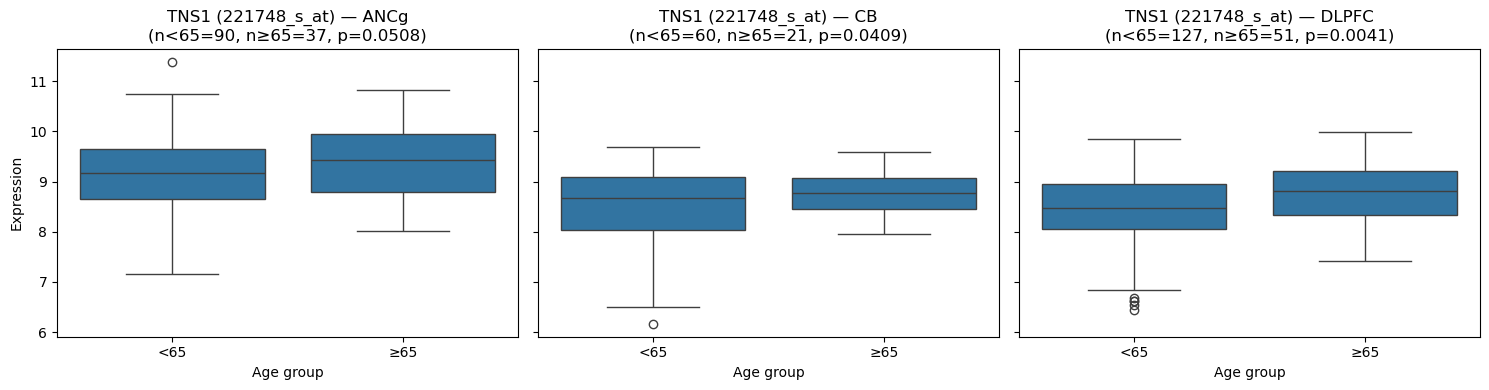

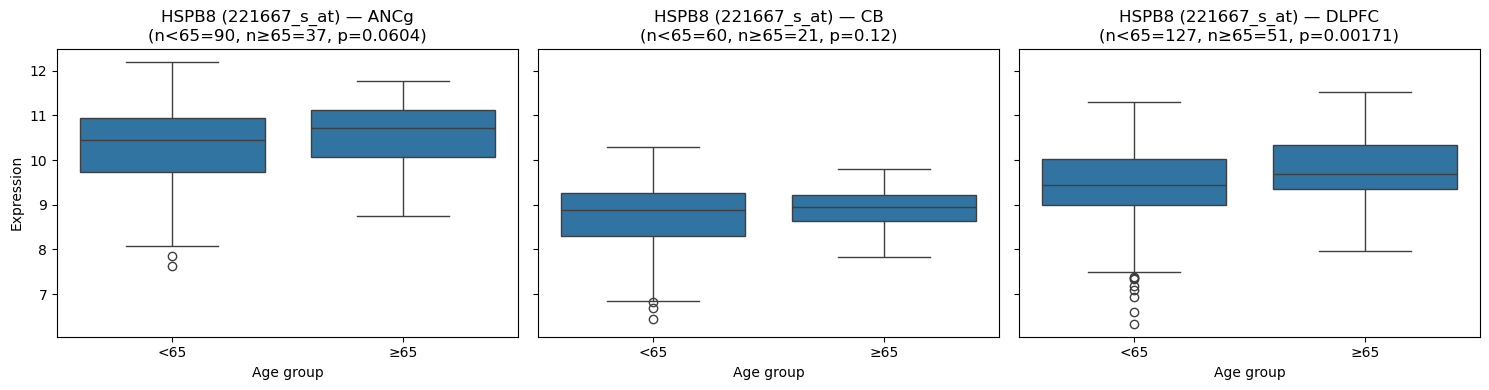

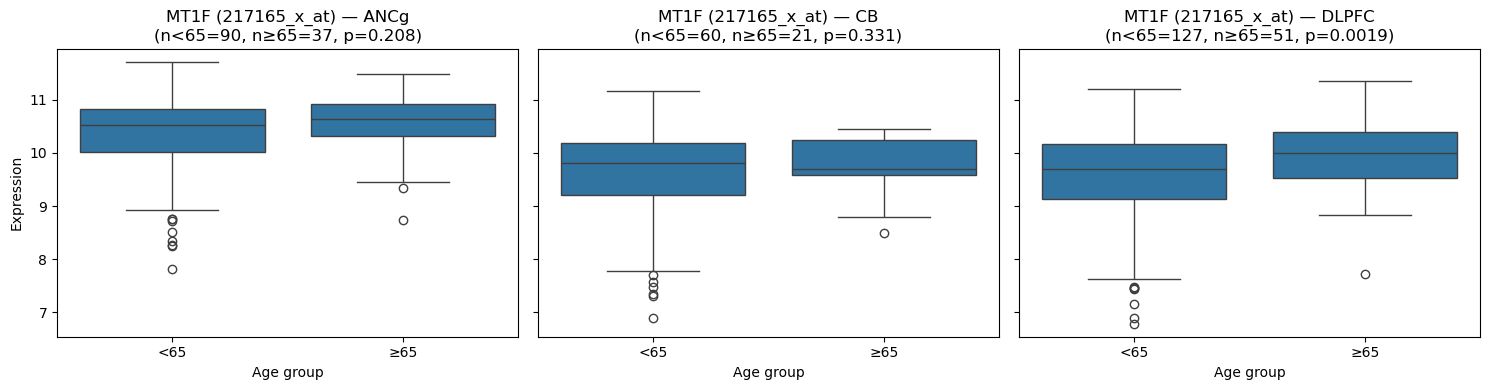

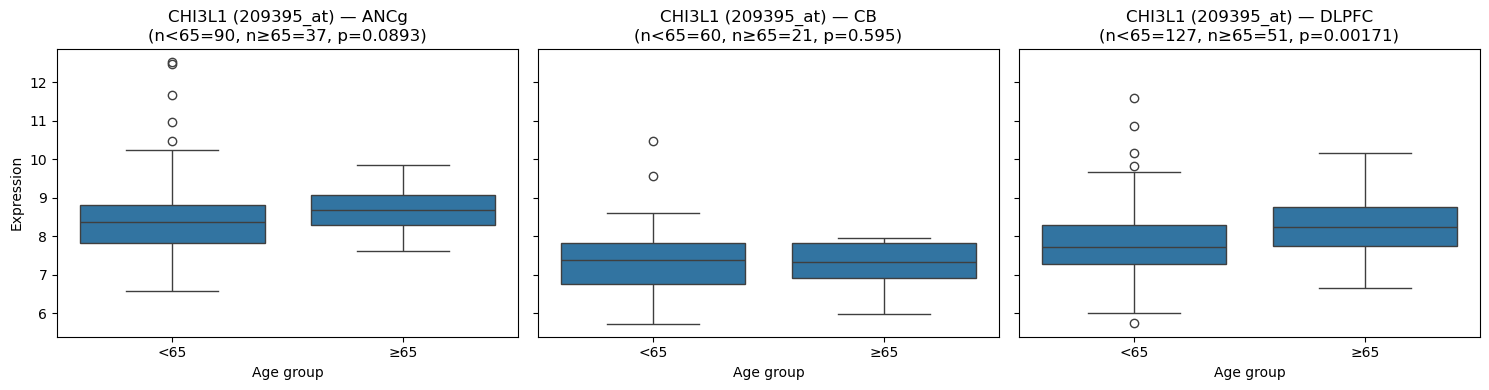

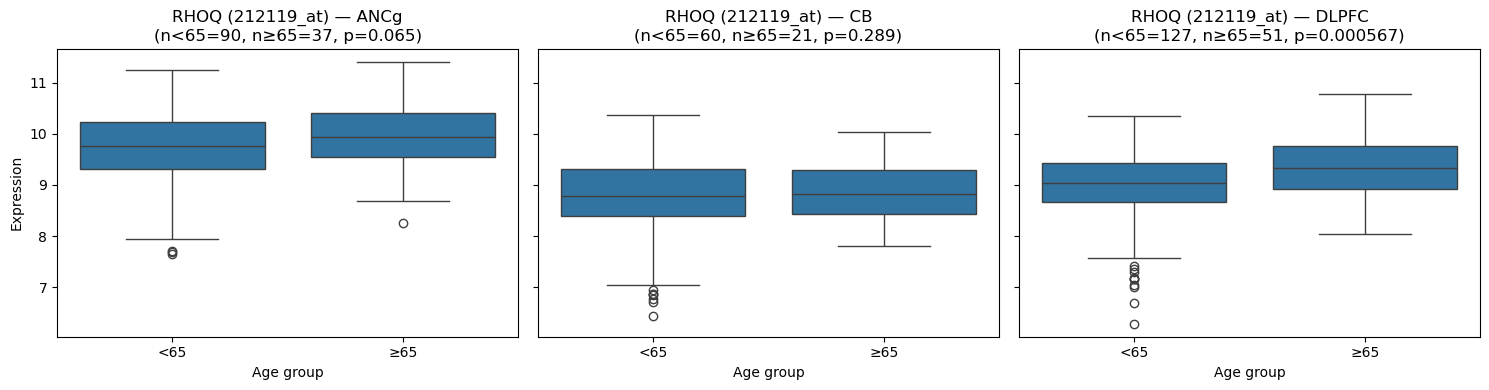

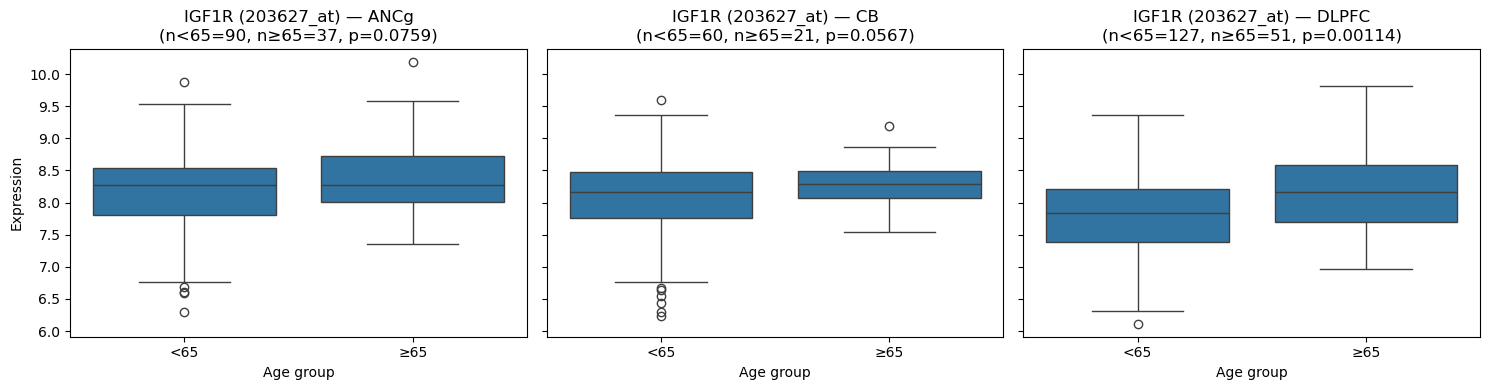

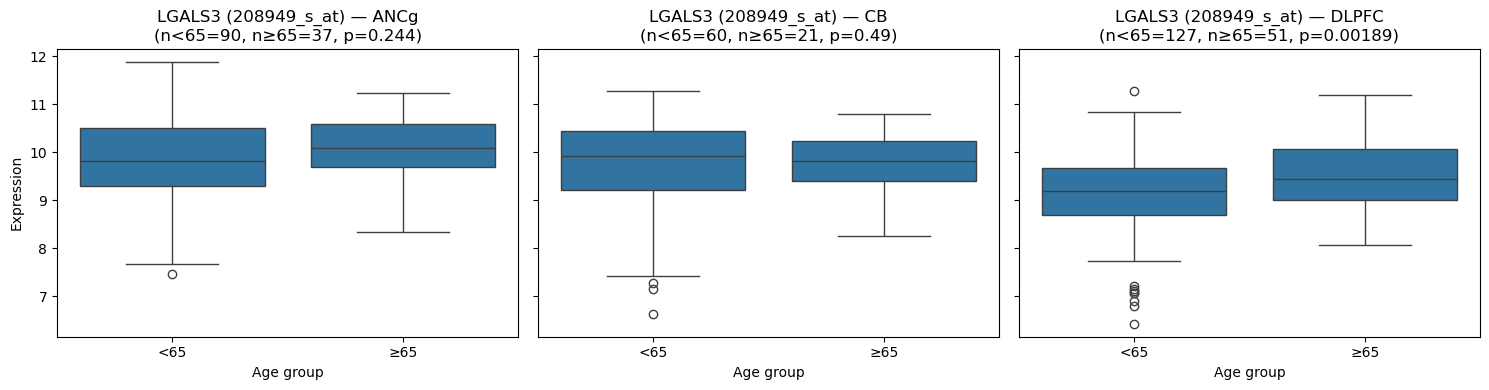

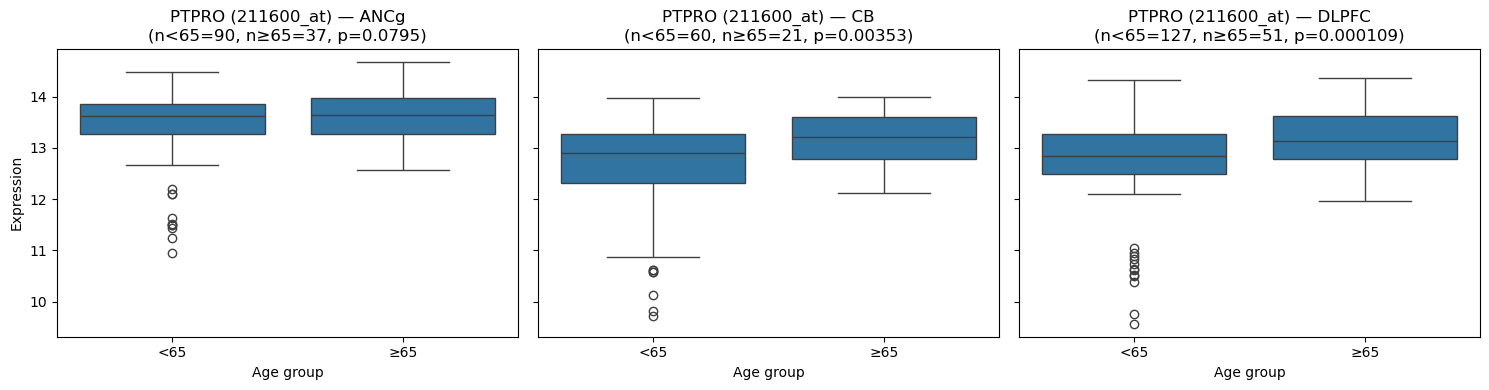

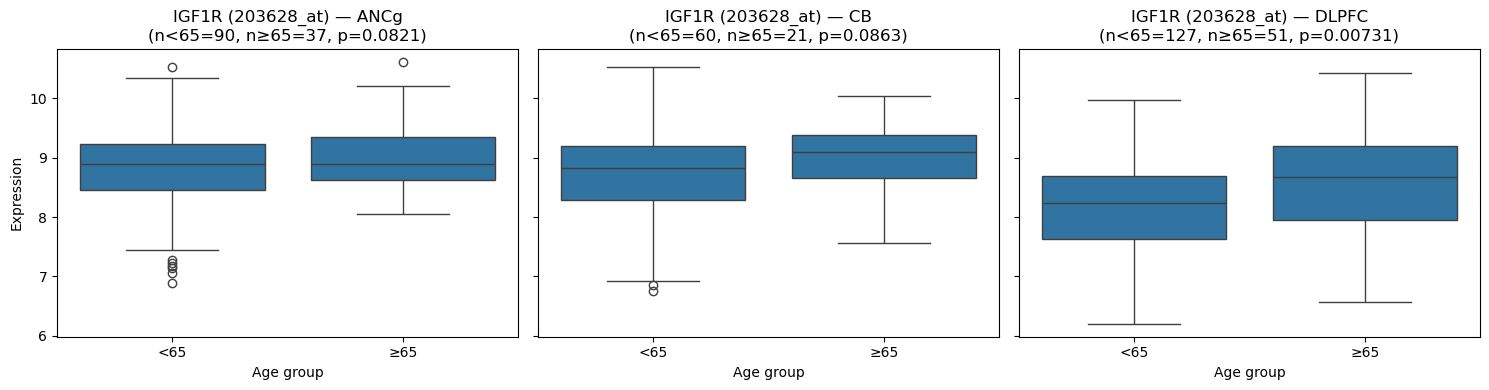

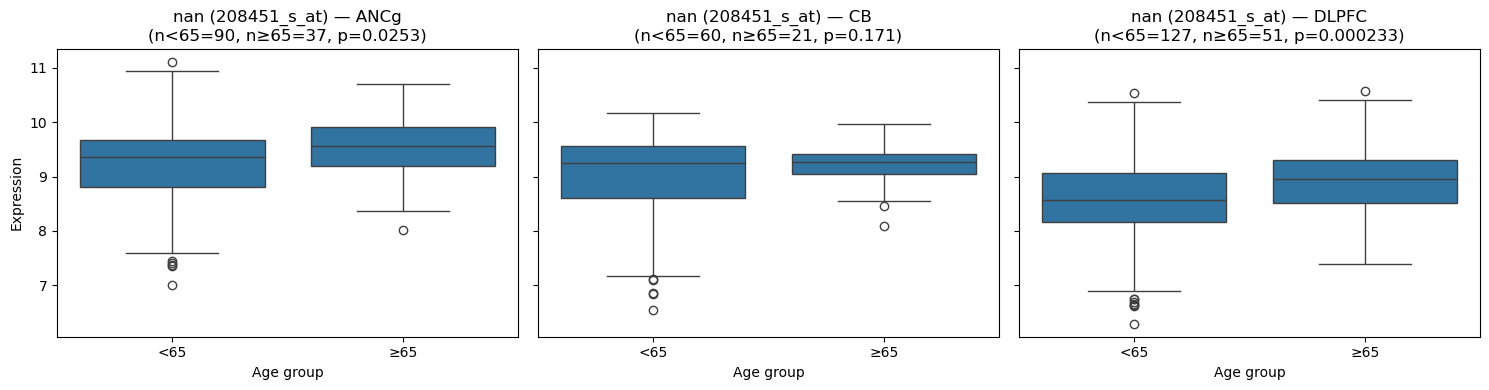

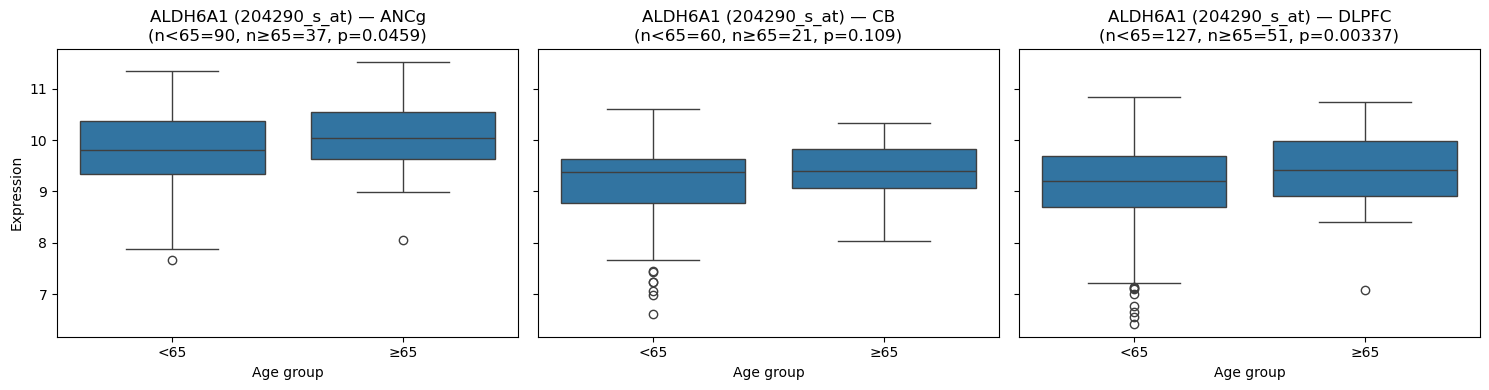

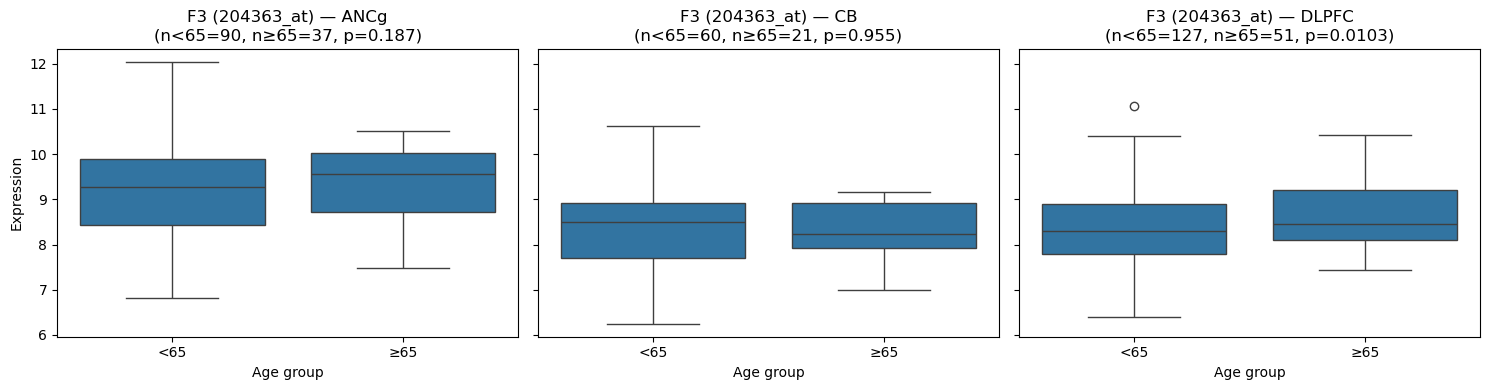

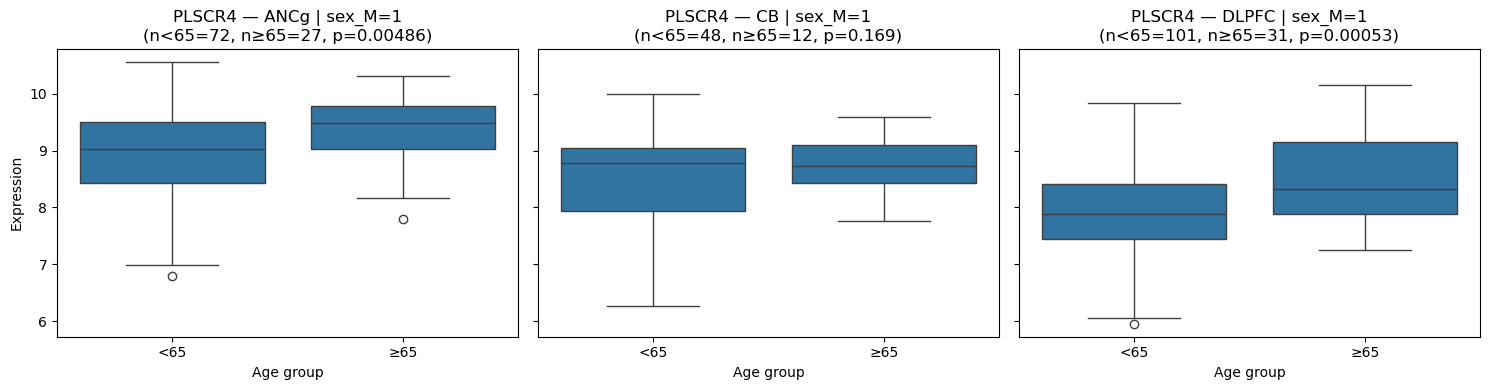

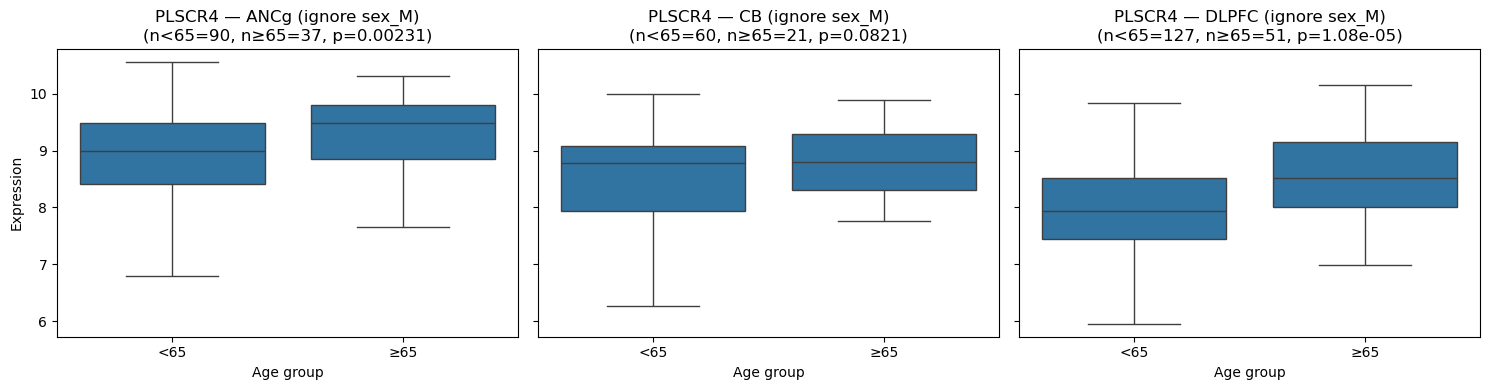

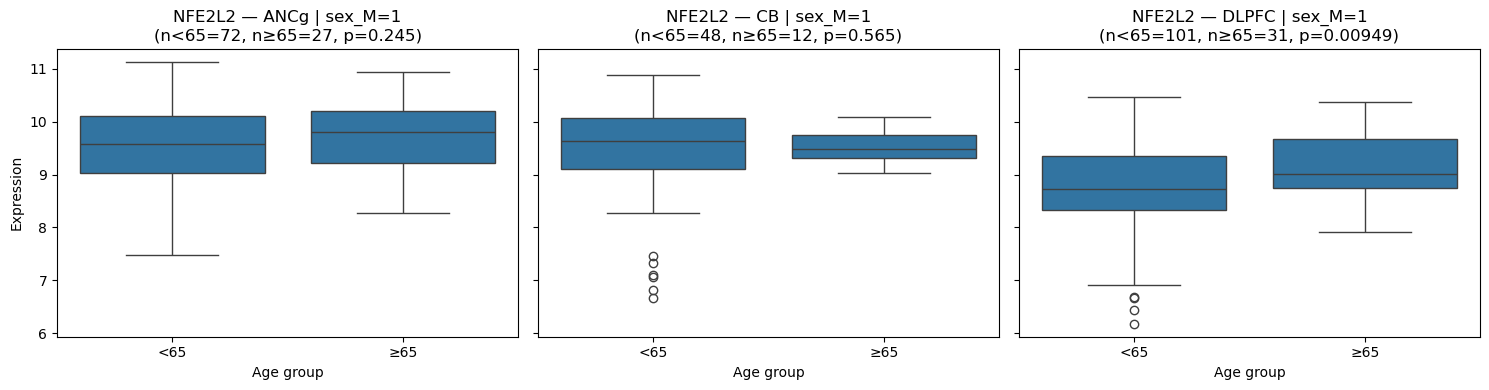

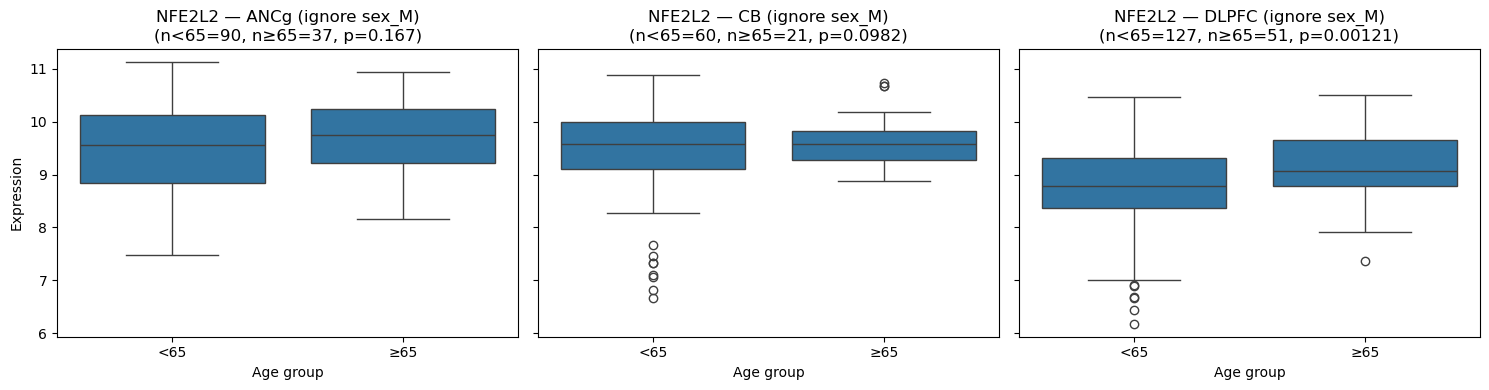

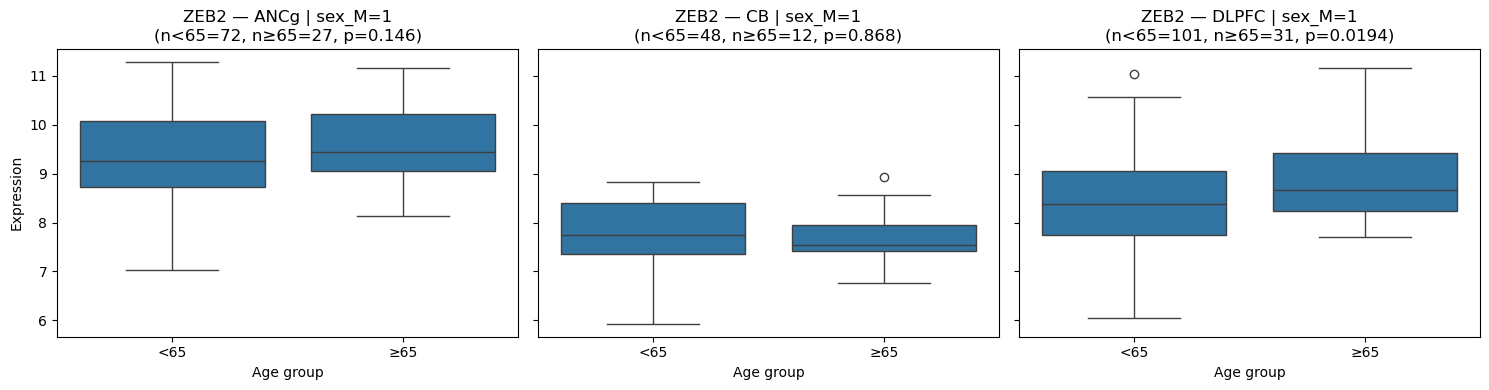

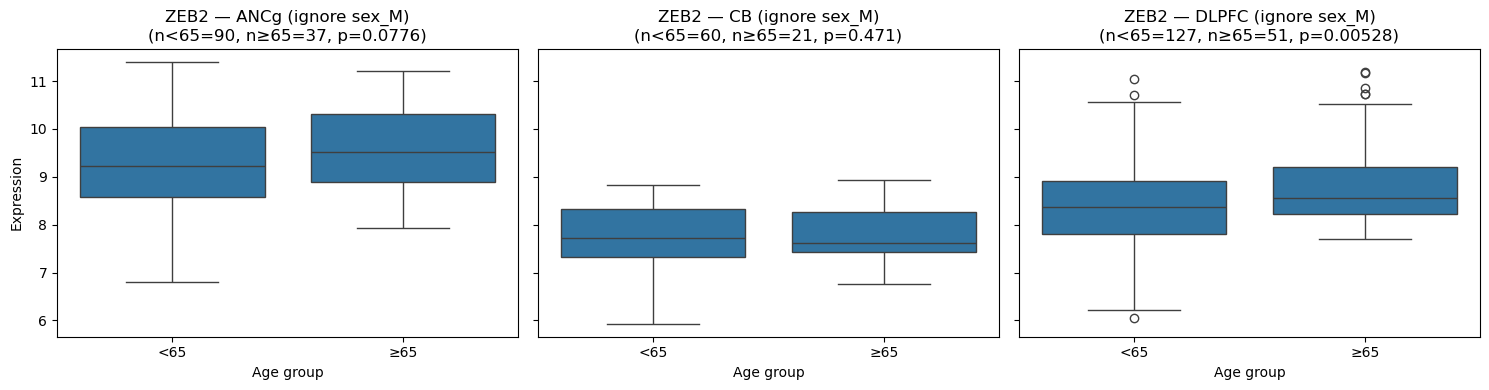

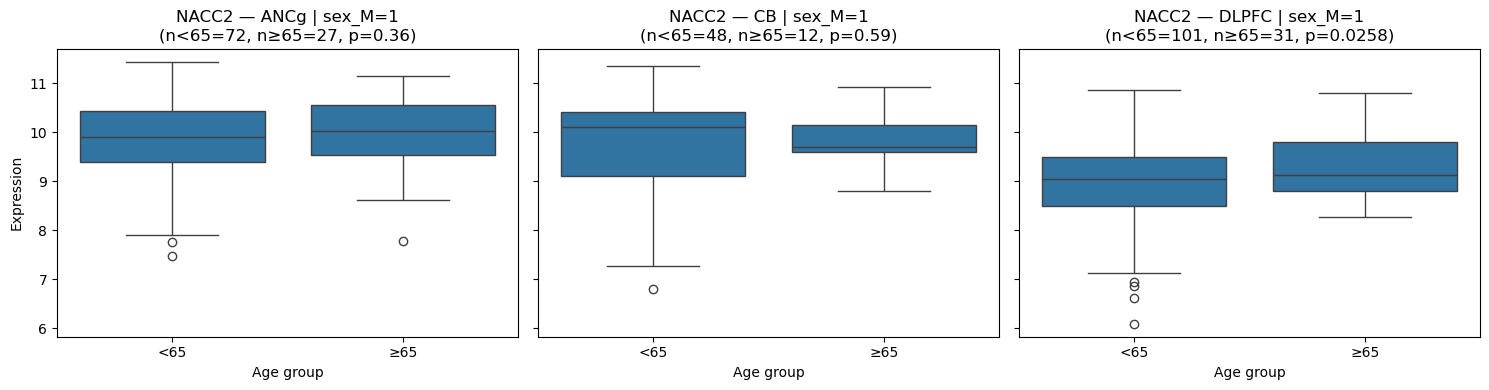

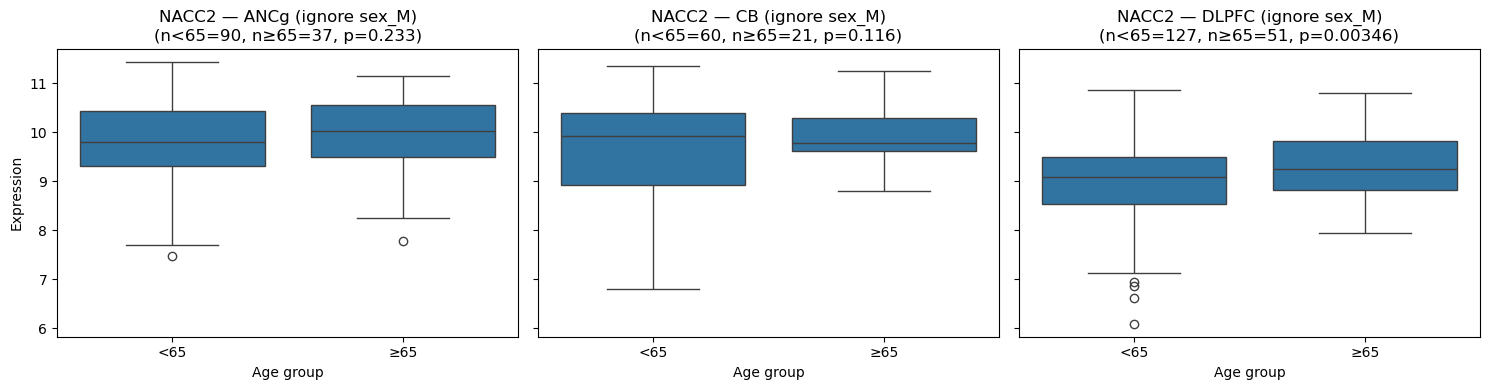

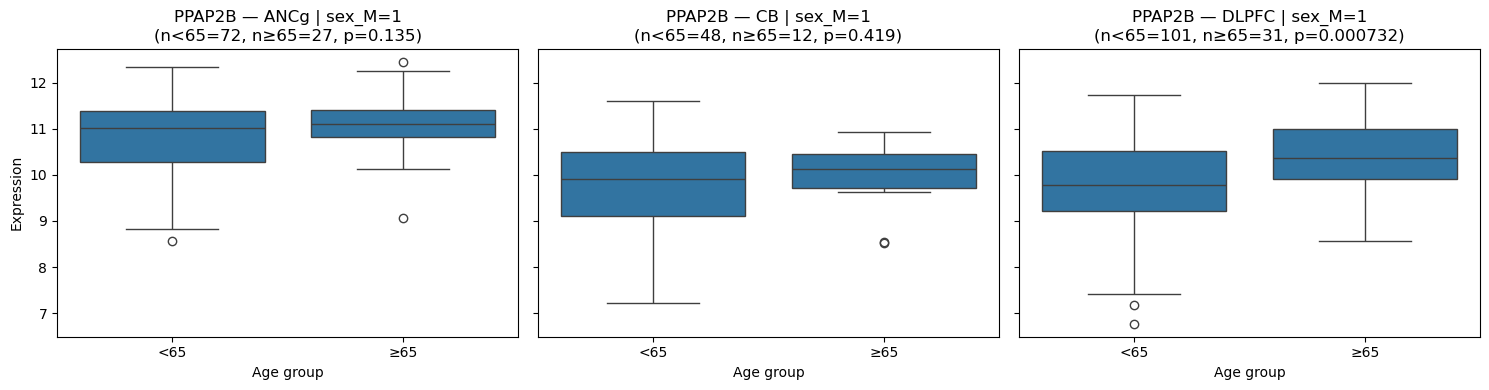

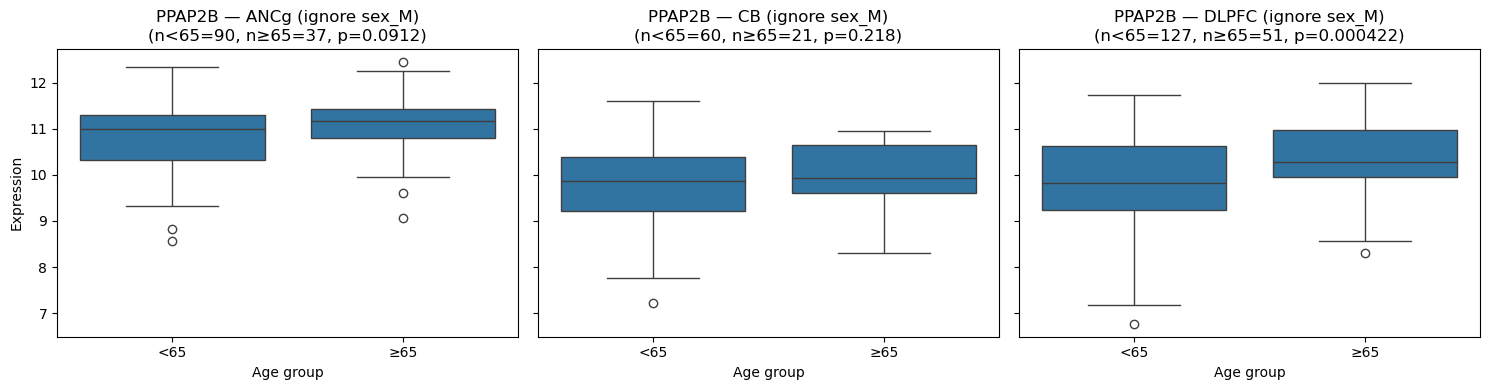

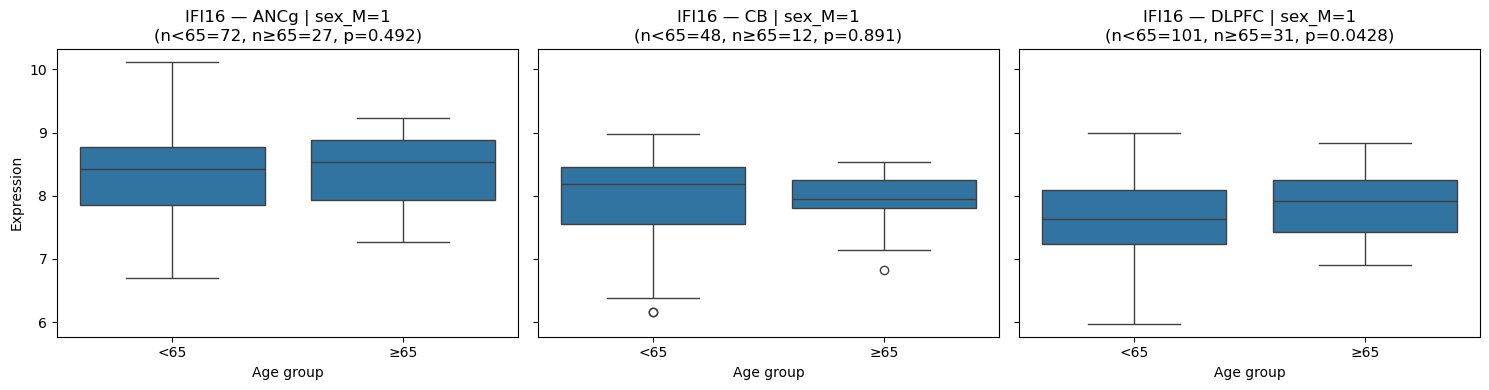

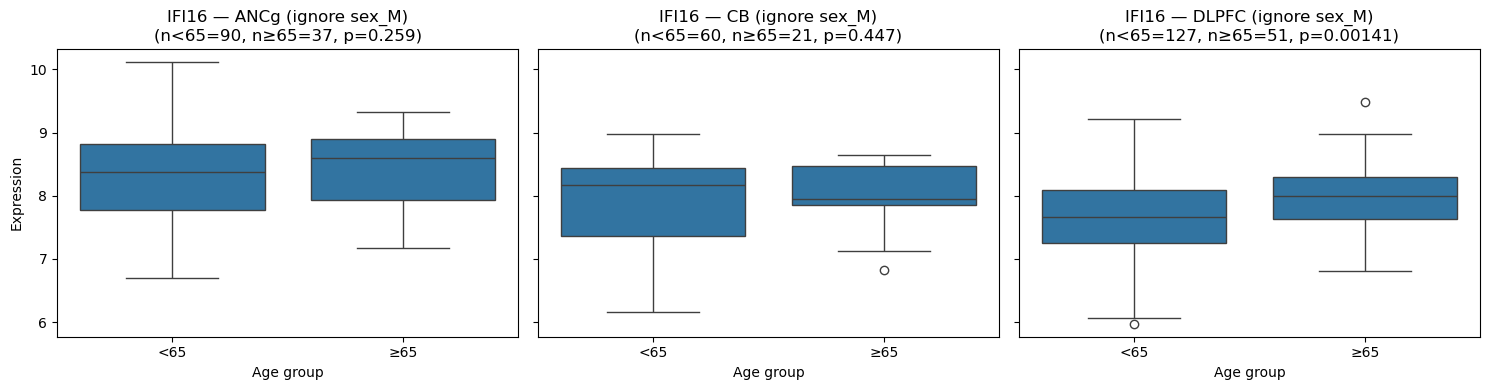

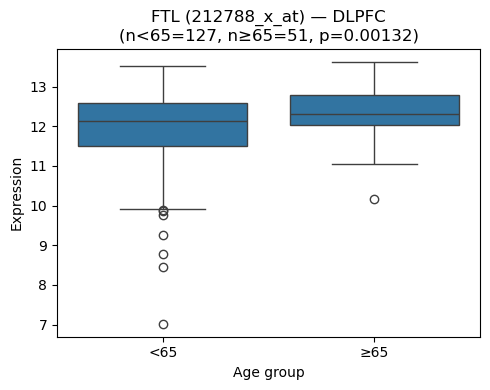

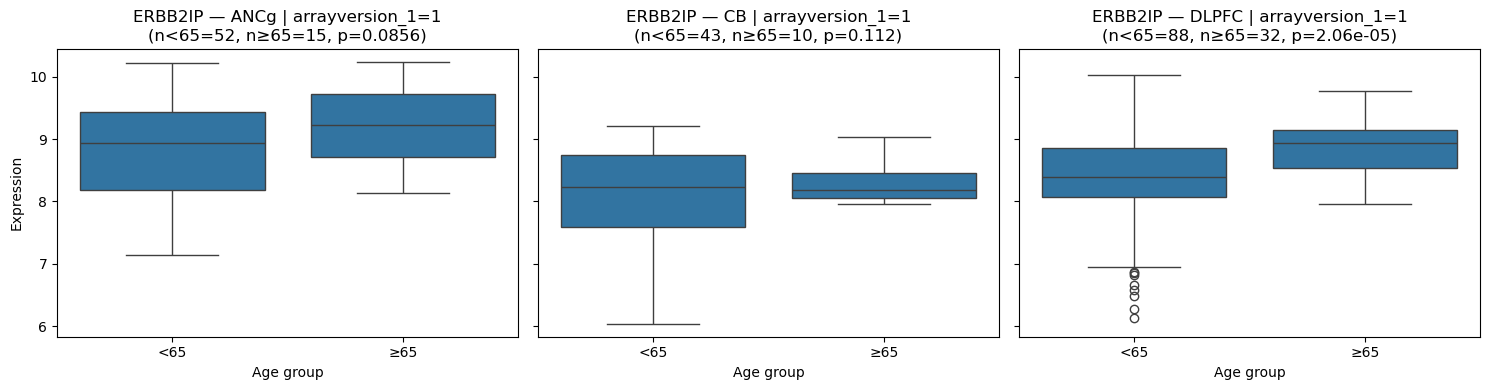

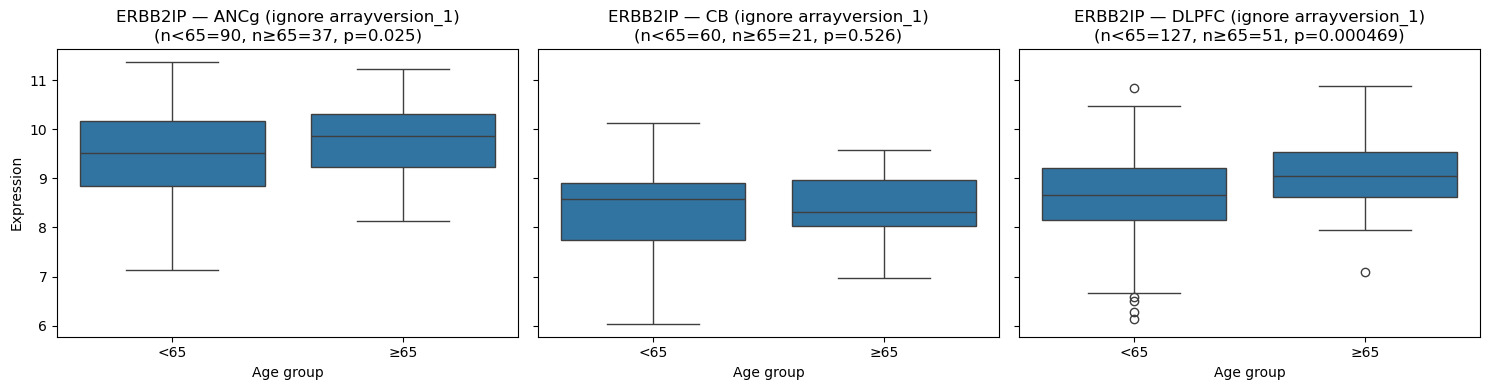

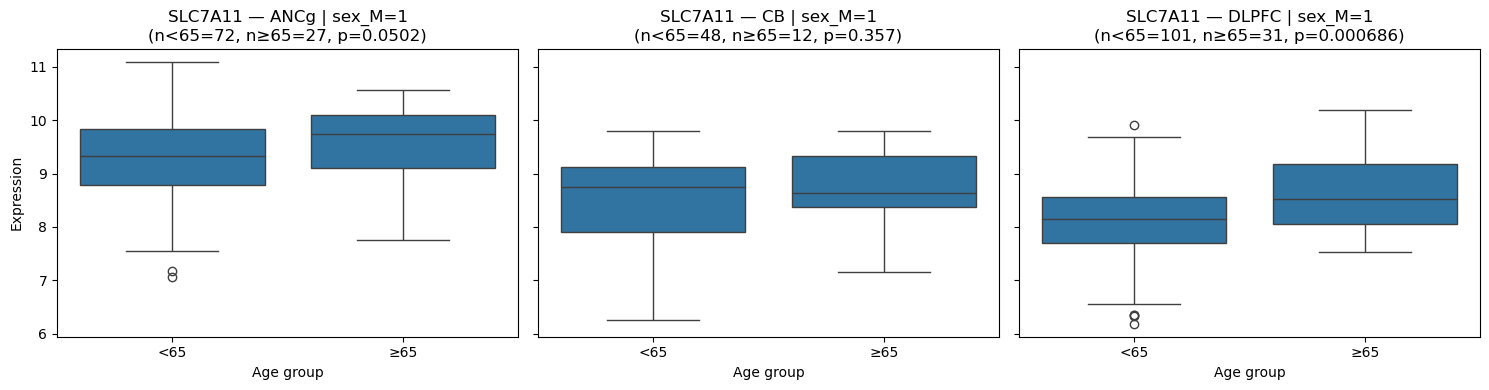

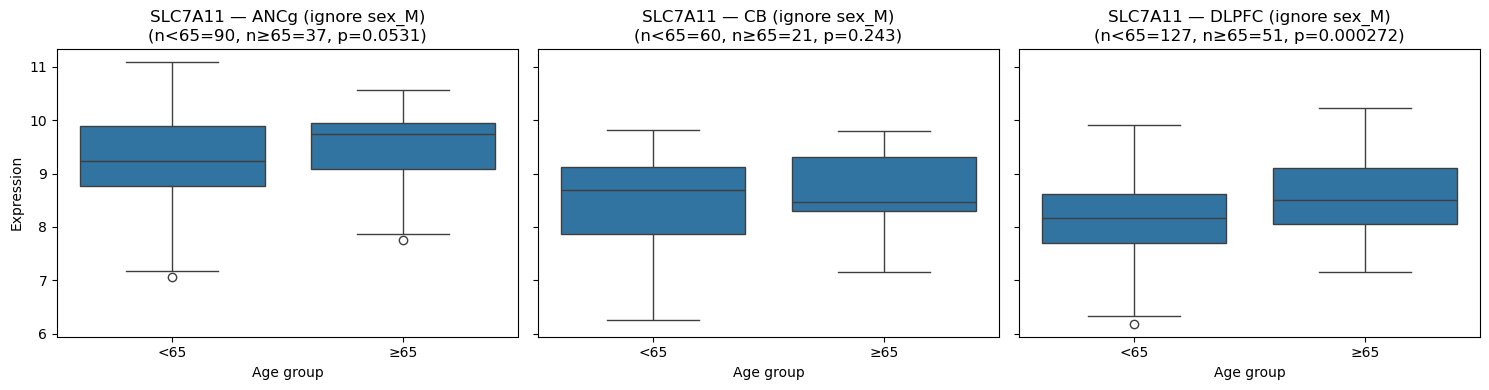

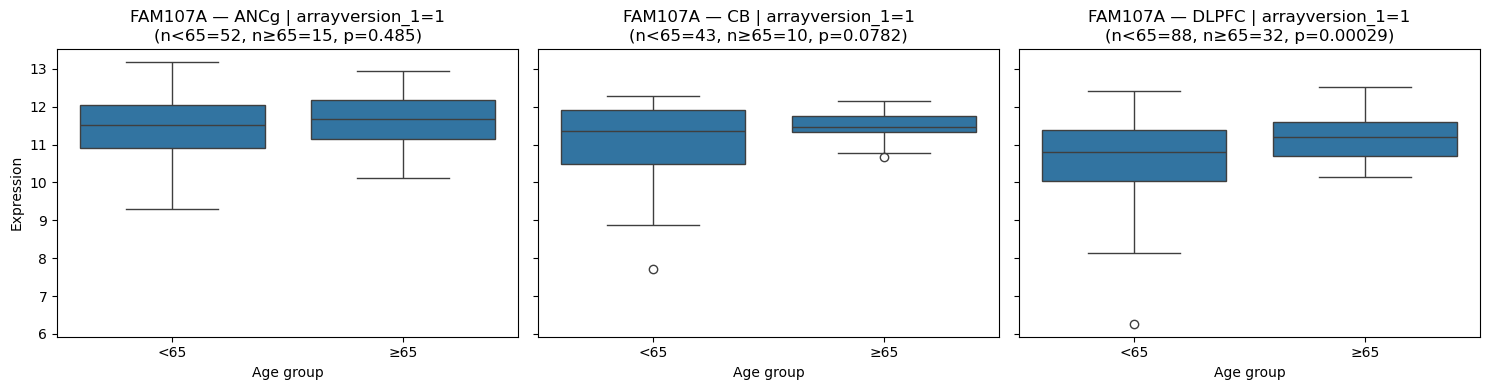

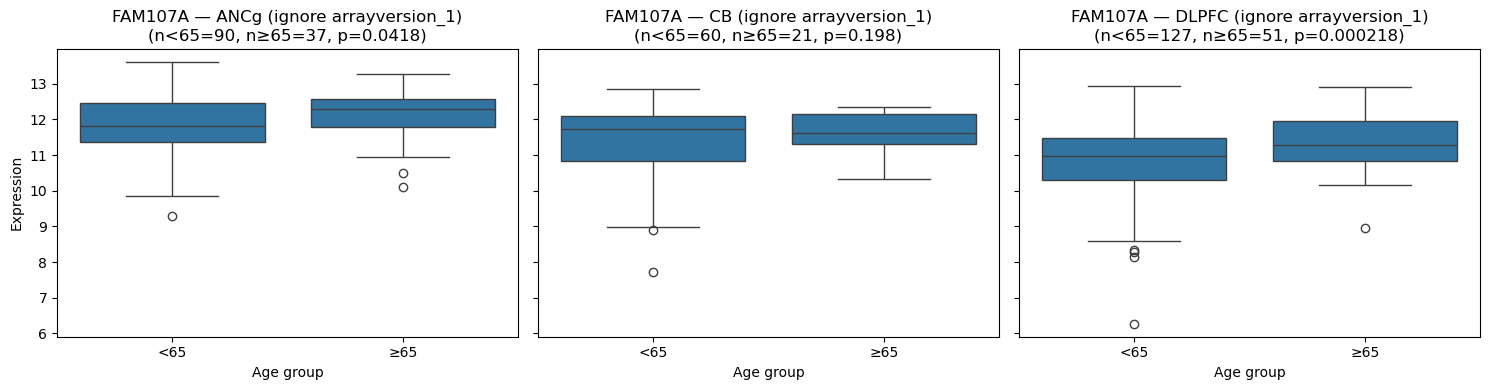

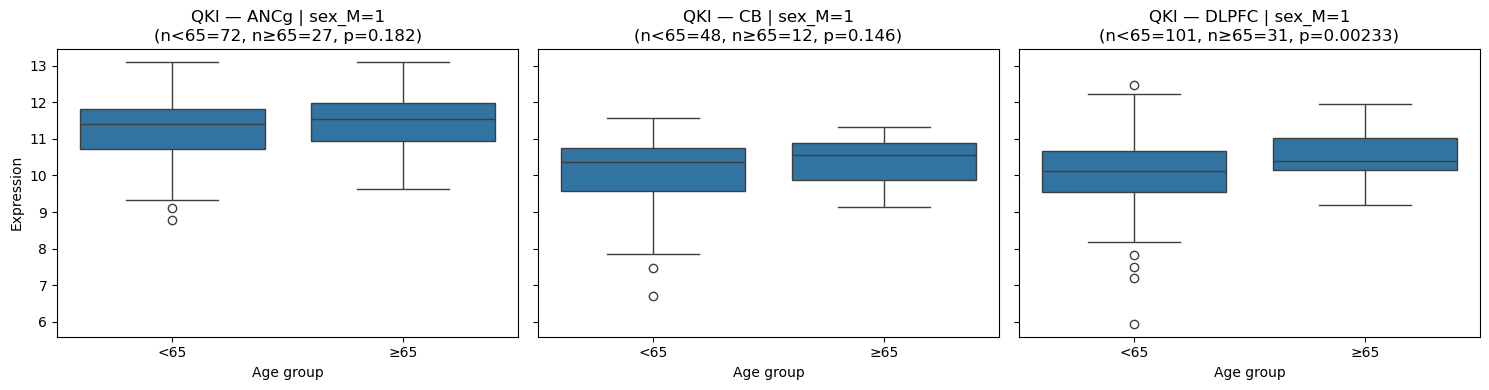

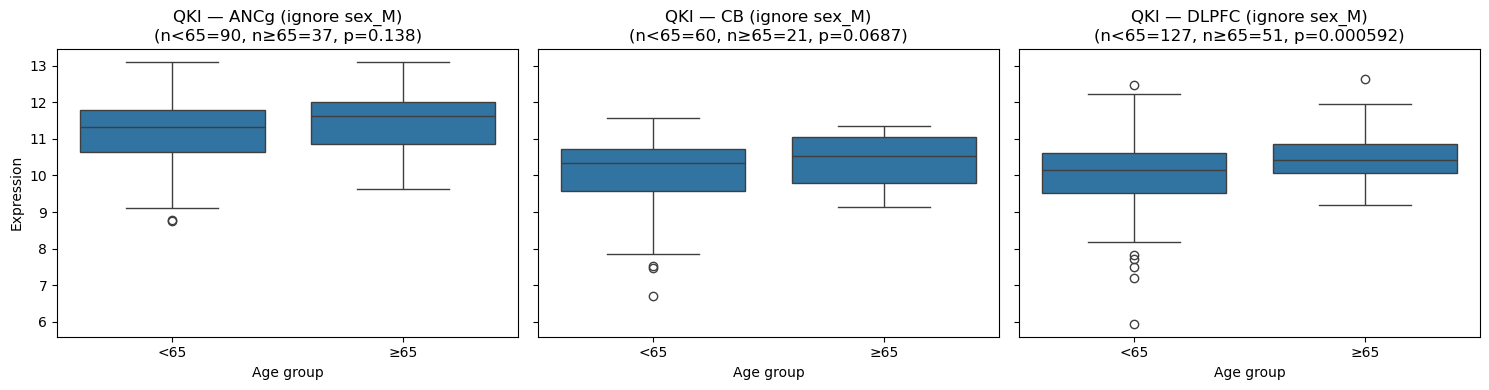

,covariate,type,region,n_<65,n_≥65,t_stat,p_value
0,221748_s_at,gene,ANCg,90,37,-1.986237,0.050831
1,221748_s_at,gene,CB,60,21,-2.086949,0.040864
2,221748_s_at,gene,DLPFC,127,51,-2.937660,0.004097
3,221667_s_at,gene,ANCg,90,37,-1.903187,0.060364
4,221667_s_at,gene,CB,60,21,-1.577724,0.119893
...,...,...,...,...,...,...,...
92,sex_M:212636_at,ind×gene (subset by ind=1),CB,48,12,-1.489926,0.146362
93,sex_M:212636_at,ind×gene (subset by ind=1),DLPFC,101,31,-3.155117,0.002326
94,sex_M:212636_at,ind×gene (ignore ind),ANCg,90,37,-1.498433,0.137986
95,sex_M:212636_at,ind×gene (ignore ind),CB,60,21,-1.853560,0.068700


In [69]:
# Post-hoc: region-wise DE checks for BH-significant covariates
# Cases:
# 1) gene only → per-region t-test by age; boxplots
# 2a) interaction w/ non-region indicator → per-region subset where indicator==1 (or sex M / version 1), t-test by age; boxplots
# 2b) same as 2a but ignore indicator; just gene by age per-region; boxplots
# 3) interaction w/ region indicator → only that region; t-test by age; boxplots

# Assumes: sig_covariates, df_expression, df_arraymeta, df_genemeta available
# df_genemeta: rows include "sym"; columns are probe IDs

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

# --- helpers ---
probe_to_symbol = df_genemeta.loc["sym"].to_dict()  # fast lookup

def age_group_series(meta):
    return np.where(meta["age"] < age_cutoff, f"<{age_cutoff}", f"≥{age_cutoff}")

def indicator_mask(meta, ind):
    # handles sex_M and arrayversion_1 and binary meta columns
    if ind == "sex_M":
        return meta["sex"] == "M"
    if ind == "arrayversion_1":
        return meta["arrayversion"] == 1
    if ind in meta.columns:
        return meta[ind] == 1
    # unknown indicator → empty mask
    return pd.Series(False, index=meta.index)

def ttest_two_groups(vals, groups):
    a = vals[groups == f"<{age_cutoff}"].dropna()
    b = vals[groups == f"≥{age_cutoff}"].dropna()
    if len(a) > 1 and len(b) > 1:
        stat, p = ttest_ind(a, b, equal_var=False)
    else:
        stat, p = np.nan, np.nan
    return len(a), len(b), stat, p

def boxplot_by_age(ax, y, groups, title):
    sns.boxplot(x=groups, y=y, ax=ax)
    ax.set_xlabel("Age group")
    ax.set_ylabel("Expression")
    ax.set_title(title)

regions = {"ANCg": "region.ancg", "CB": "region.cb", "DLPFC": "region.dlpfc"}

# precompute for speed
meta_all = df_arraymeta.copy()
meta_all["age_group"] = age_group_series(meta_all)

# --- main routine ---
results = []  # collect t-test outputs

for cov in sig_covariates:
    if ":" not in cov:
        # ---------- Case 1: gene only ----------
        gene = cov
        symbol = probe_to_symbol.get(gene, gene)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
        for ax, (rname, rcol) in zip(axes, regions.items()):
            m_reg = meta_all[rcol] == 1
            expr = df_expression.loc[m_reg, gene]
            groups = meta_all.loc[m_reg, "age_group"]
            n1, n2, stat, p = ttest_two_groups(expr, groups)
            boxplot_by_age(ax, expr.values, groups.values, f"{symbol} ({gene}) — {rname}\n(n<{age_cutoff}={n1}, n≥{age_cutoff}={n2}, p={p:.3g})")
            results.append({"covariate": cov, "type": "gene", "region": rname,
                            f"n_<{age_cutoff}": n1, f"n_≥{age_cutoff}": n2, "t_stat": stat, "p_value": p})
        plt.tight_layout()
        plt.show()

    else:
        ind, gene = cov.split(":")
        symbol = probe_to_symbol.get(gene, gene)

        if ind.startswith("region."):
            # ---------- Case 3: interaction with region indicator ----------
            # Look only at that region
            rname = {v: k for k, v in regions.items()}.get(ind, ind)
            m_reg = meta_all[ind] == 1
            expr = df_expression.loc[m_reg, gene]
            groups = meta_all.loc[m_reg, "age_group"]
            n1, n2, stat, p = ttest_two_groups(expr, groups)
            plt.figure(figsize=(5, 4))
            boxplot_by_age(plt.gca(), expr.values, groups.values,
                           f"{symbol} ({gene}) — {rname}\n(n<{age_cutoff}={n1}, n≥{age_cutoff}={n2}, p={p:.3g})")
            plt.tight_layout(); plt.show()
            results.append({"covariate": cov, "type": "region×gene", "region": rname,
                            f"n_<{age_cutoff}": n1, f"n_≥{age_cutoff}": n2, "t_stat": stat, "p_value": p})

        else:
            # ---------- Case 2a: interaction w/ non-region indicator; subset by indicator==1 in each region ----------
            fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
            for ax, (rname, rcol) in zip(axes, regions.items()):
                m_reg = meta_all[rcol] == 1
                sub_meta = meta_all.loc[m_reg]
                m_ind = indicator_mask(sub_meta, ind)
                if m_ind.sum() == 0:
                    ax.set_title(f"{symbol} — {rname}\n(no {ind}=1)")
                    ax.axis("off")
                    results.append({"covariate": cov, "type": "ind×gene (subset by ind=1)", "region": rname,
                                    f"n_<{age_cutoff}": 0, f"n_≥{age_cutoff}": 0, "t_stat": np.nan, "p_value": np.nan})
                    continue
                expr = df_expression.loc[sub_meta.index[m_ind], gene]
                groups = sub_meta.loc[m_ind, "age_group"]
                n1, n2, stat, p = ttest_two_groups(expr, groups)
                boxplot_by_age(ax, expr.values, groups.values,
                               f"{symbol} — {rname} | {ind}=1\n(n<{age_cutoff}={n1}, n≥{age_cutoff}={n2}, p={p:.3g})")
                results.append({"covariate": cov, "type": "ind×gene (subset by ind=1)", "region": rname,
                                f"n_<{age_cutoff}": n1, f"n_≥{age_cutoff}": n2, "t_stat": stat, "p_value": p})
            plt.tight_layout(); plt.show()

            # ---------- Case 2b: same gene, ignore indicator; per-region t-test ----------
            fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
            for ax, (rname, rcol) in zip(axes, regions.items()):
                m_reg = meta_all[rcol] == 1
                expr = df_expression.loc[m_reg, gene]
                groups = meta_all.loc[m_reg, "age_group"]
                n1, n2, stat, p = ttest_two_groups(expr, groups)
                boxplot_by_age(ax, expr.values, groups.values,
                               f"{symbol} — {rname} (ignore {ind})\n(n<{age_cutoff}={n1}, n≥{age_cutoff}={n2}, p={p:.3g})")
                results.append({"covariate": cov, "type": "ind×gene (ignore ind)", "region": rname,
                                f"n_<{age_cutoff}": n1, f"n_≥{age_cutoff}": n2, "t_stat": stat, "p_value": p})
            plt.tight_layout(); plt.show()

# Results table (per-test)
region_de_results = pd.DataFrame(results)
display(region_de_results)


In [70]:
# BH across all region-wise tests; summarize significant results

alpha_bh = 0.1  # change if needed

if 'region_de_results' not in globals():
    raise RuntimeError("region_de_results not found. Run the region-wise testing cell first.")

res = region_de_results.dropna(subset=["p_value"]).copy()

# q-values (BH)
rej, qvals, _, _ = multipletests(res["p_value"].values, alpha=alpha_bh, method="fdr_bh")
res["q_value"] = qvals
res["significant"] = rej

# probe → symbol
probe_to_symbol = df_genemeta.loc["sym"].to_dict()

# parse covariate into indicator / gene
def parse_cov(c):
    if ":" in c:
        ind, gene = c.split(":", 1)
        return ind, gene
    return None, c

res[["indicator","gene"]] = res["covariate"].apply(lambda c: pd.Series(parse_cov(c)))
res["gene_symbol"] = res["gene"].map(lambda g: probe_to_symbol.get(g, g))

# human-readable restriction note (only when we explicitly subset to indicator==1)
def restriction_note(row):
    if row["type"].startswith("ind×gene (subset"):
        ind = row["indicator"]
        if ind == "sex_M": return "subset: sex=M"
        if ind == "arrayversion_1": return "subset: arrayversion=1"
        if isinstance(ind, str) and ind.startswith("lab."): return f"subset: {ind}=1"
        return f"subset: {ind}=1"
    return ""

res["restriction"] = res.apply(restriction_note, axis=1)

# significant only
sig = res[res["significant"]].copy()
sig = sig.sort_values("q_value")

# final report
report_cols = [
    "gene_symbol","gene","region","covariate","indicator","restriction",
    "type",f"n_<{age_cutoff}",f"n_≥{age_cutoff}","t_stat","p_value","q_value"
]
sig_report = sig.loc[:, report_cols]
display(sig_report)
print(f"\nBH @ {alpha_bh}: {len(sig_report)} significant tests")

# Optional: compact per-gene summary (regions where DE detected)
if not sig_report.empty:
    per_gene = (sig_report.groupby(["gene_symbol","gene"])
                .apply(lambda d: ", ".join(f"{r} ({t}{' | '+n if n else ''})"
                                           for r,t,n in zip(d["region"], d["type"], d["restriction"])))
                .reset_index(name="regions_significant"))
    display(per_gene)


,gene_symbol,gene,region,covariate,indicator,restriction,type,n_<65,n_≥65,t_stat,p_value,q_value
75,ERBB2IP,217941_s_at,DLPFC,arrayversion_1:217941_s_at,arrayversion_1,subset: arrayversion=1,ind×gene (subset by ind=1),88,32,-4.477066,0.000021,0.001001
41,PLSCR4,218901_at,DLPFC,sex_M:218901_at,sex_M,,ind×gene (ignore ind),127,51,-4.631374,0.000011,0.001001
23,PTPRO,211600_at,DLPFC,211600_at,None,,gene,127,51,-3.980816,0.000109,0.003540
84,SLC7A11,209921_at,DLPFC,sex_M:209921_at,sex_M,,ind×gene (ignore ind),127,51,-3.775620,0.000272,0.004018
29,NaN,208451_s_at,DLPFC,208451_s_at,None,,gene,127,51,-3.809906,0.000233,0.004018
87,FAM107A,209074_s_at,DLPFC,arrayversion_1:209074_s_at,arrayversion_1,subset: arrayversion=1,ind×gene (subset by ind=1),88,32,-3.756953,0.000290,0.004018
90,FAM107A,209074_s_at,DLPFC,arrayversion_1:209074_s_at,arrayversion_1,,ind×gene (ignore ind),127,51,-3.809115,0.000218,0.004018
78,ERBB2IP,217941_s_at,DLPFC,arrayversion_1:217941_s_at,arrayversion_1,,ind×gene (ignore ind),127,51,-3.602564,0.000469,0.004784
38,PLSCR4,218901_at,DLPFC,sex_M:218901_at,sex_M,subset: sex=M,ind×gene (subset by ind=1),101,31,-3.684859,0.000530,0.004784
65,PPAP2B,212226_s_at,DLPFC,sex_M:212226_s_at,sex_M,,ind×gene (ignore ind),127,51,-3.632115,0.000422,0.004784



BH @ 0.1: 37 significant tests


/var/folders/fk/nfp329xj1v3g44j1s4lnjb4w0000gr/T/ipykernel_83380/537759489.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: ", ".join(f"{r} ({t}{' | '+n if n else ''})"


,gene_symbol,gene,regions_significant
0,ALDH6A1,204290_s_at,DLPFC (gene)
1,CHI3L1,209395_at,DLPFC (gene)
2,ERBB2IP,217941_s_at,DLPFC (ind×gene (subset by ind=1) | subset: ar...
3,F3,204363_at,DLPFC (gene)
4,FAM107A,209074_s_at,DLPFC (ind×gene (subset by ind=1) | subset: ar...
5,FTL,212788_x_at,DLPFC (region×gene)
6,HSPB8,221667_s_at,DLPFC (gene)
7,IFI16,206332_s_at,DLPFC (ind×gene (ignore ind))
8,IGF1R,203627_at,DLPFC (gene)
9,IGF1R,203628_at,DLPFC (gene)


/var/folders/fk/nfp329xj1v3g44j1s4lnjb4w0000gr/T/ipykernel_83380/1288099169.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disp_top["Context"] = wrap_col(disp_top["Context"], width=25)


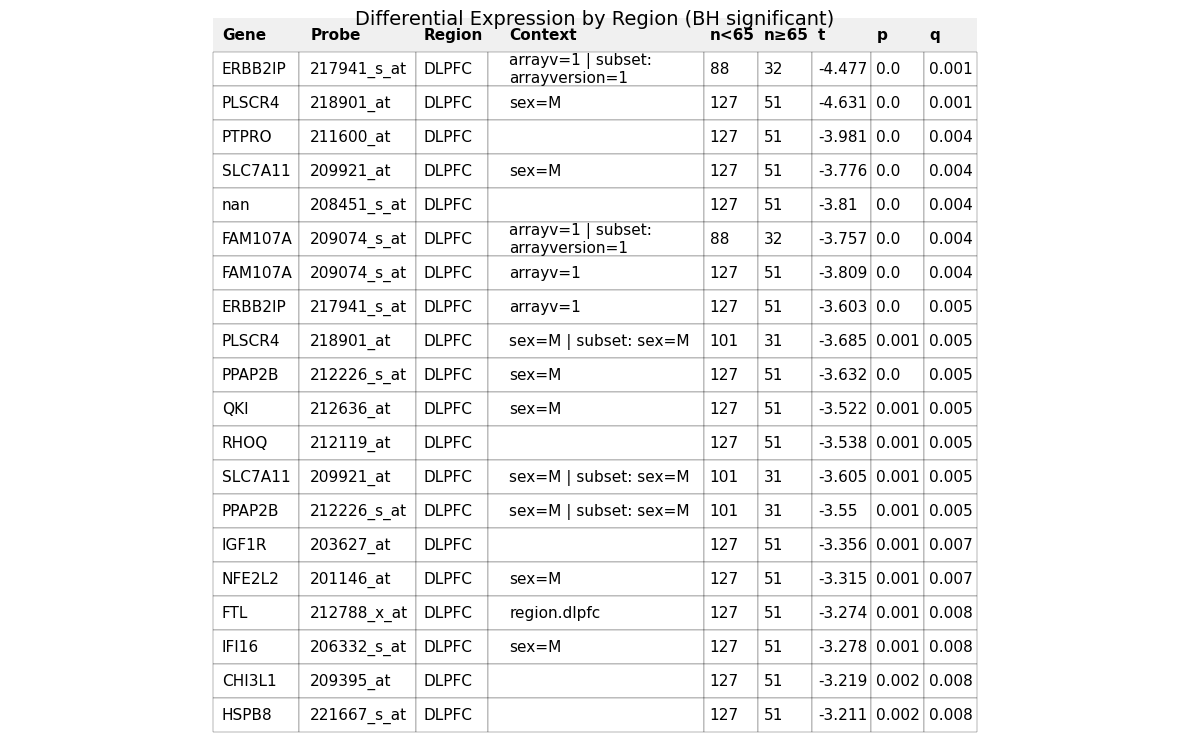

Saved slide image: BH0.1_region_DE_table_65.png


In [72]:
# Make a slide-friendly table image from `sig_report`

import numpy as np
import matplotlib.pyplot as plt
import textwrap

def wrap_col(series, width=20):
    return series.apply(lambda x: "\n".join(textwrap.wrap(str(x), width=width)))

if sig_report.empty:
    raise RuntimeError("sig_report is empty. Run your BH step first.")

# 1) Build a compact display table
disp = sig_report.copy()

# Short, presentation-friendly columns
disp = disp.rename(columns={
    "gene_symbol": "Gene",
    "gene": "Probe",
    "region": "Region",
    "restriction": "Context",
    f"n_<{age_cutoff}": f"n<{age_cutoff}",
    f"n_≥{age_cutoff}": f"n≥{age_cutoff}",
    "t_stat": "t",
    "p_value": "p",
    "q_value": "q"
})

# Derive a simple context column (indicator + any restriction)
def _context(row):
    if row["indicator"] and isinstance(row["indicator"], str):
        base = row["indicator"].replace("sex_M", "sex=M").replace("arrayversion_1", "arrayv=1")
        return f"{base}{(' | ' + row['Context']) if row['Context'] else ''}"
    return row["Context"] or ""
disp["Context"] = disp.apply(_context, axis=1)

# Choose and order columns for slides
cols = ["Gene", "Probe", "Region", "Context", f"n<{age_cutoff}", f"n≥{age_cutoff}", "t", "p", "q"]
disp = disp[cols]

# Round numbers for readability
for c in ["t", "p", "q"]:
    if c in disp.columns:
        disp[c] = disp[c].astype(float).round(3)

# Optional: sort by q-value ascending (most significant first)
disp = disp.sort_values("q", kind="stable").reset_index(drop=True)

# Optional: limit rows for a single slide (e.g., top 20)
topN = min(20, len(disp))
disp_top = disp.head(topN)

disp_top["Context"] = wrap_col(disp_top["Context"], width=25)

# 2) Render with matplotlib and save
def save_table_as_png(df, title, filename, fontsize=11, col_widths=None, dpi=300):
    fig, ax = plt.subplots(figsize=(12, 0.5 + 0.35*len(df)))  # height scales with rows
    ax.axis("off")

    # Build cell text
    cell_text = df.values.tolist()
    col_labels = df.columns.tolist()

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc="center",
        cellLoc="left",
        colLoc="left",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.75)   # a bit taller rows

    # Optional fixed column widths (in axes fraction). Otherwise let matplotlib size them.
    if col_widths is not None:
        for i, w in enumerate(col_widths):
            table.auto_set_column_width(i)
            for key, cell in table.get_celld().items():
                if key[1] == i:
                    cell.set_width(w)

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#f0f0f0")
            cell.set_linewidth(0.0)
            cell.set_text_props(weight="bold")
        else:
            cell.set_linewidth(0.2)

    # Title
    ax.set_title(title, fontsize=14, pad=10)

    plt.tight_layout()
    plt.savefig(filename, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.show()

col_widths = [0.12, 0.14, 0.12, 0.42, 0.08, 0.08, 0.1, 0.1, 0.1]  # Context wider
# make 4th entry (Context) much wider

save_table_as_png(
    disp_top,
    title="Differential Expression by Region (BH significant)",
    filename=f"BH{alpha_bh}_region_DE_table_{age_cutoff}.png",
    fontsize=11,
    col_widths=col_widths
)

print(f"Saved slide image: BH{alpha_bh}_region_DE_table_{age_cutoff}.png")
